## Hybrid Bergman and LSTM residual-corrector

In [6]:
!pip install -r ../requirements.txt

   ---------------------------------------- 0.0/547.2 kB ? eta -:--:--
   ---------------------------------------- 547.2/547.2 kB 6.1 MB/s  0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 2.7/2.7 MB 15.5 MB/s  0:00:00
   ---------------------------------------- 0.0/28.1 MB ? eta -:--:--
   ----- ---------------------------------- 3.7/28.1 MB 16.8 MB/s eta 0:00:02
   ---------- ----------------------------- 7.3/28.1 MB 16.8 MB/s eta 0:00:02
   ---------------- ----------------------- 11.3/28.1 MB 17.2 MB/s eta 0:00:01
   --------------------- ------------------ 14.9/28.1 MB 17.1 MB/s eta 0:00:01
   ------------------------ --------------- 17.6/28.1 MB 16.3 MB/s eta 0:00:01
   ----------------------------- ---------- 21.0/28.1 MB 16.4 MB/s eta 0:00:01
   ---------------------------------- ----- 24.4/28.1 MB 16.3 MB/s eta 0:00:01
   ---------------------------------------  28.0/28.1 MB 16.5 MB/s eta 0:00:01
   ------

c:\Users\mohamesb\Documents\Thesis\BG-Forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\mohamesb\Documents\Thesis\BG-Forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\mohamesb\Documents\Thesis\BG-Forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


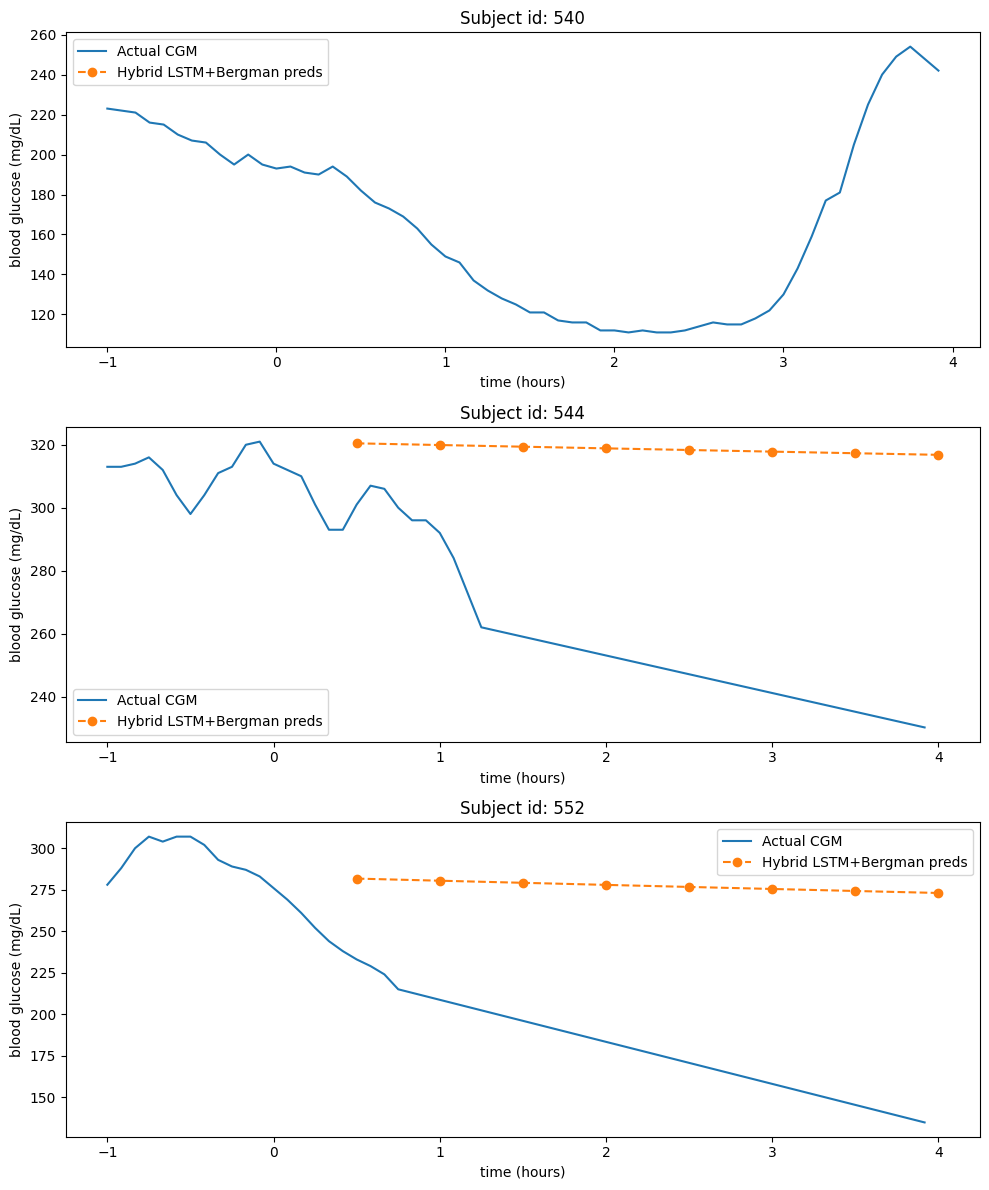

c:\Users\mohamesb\Documents\Thesis\BG-Forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\mohamesb\Documents\Thesis\BG-Forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\mohamesb\Documents\Thesis\BG-Forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


ValueError: Input contains NaN.

In [1]:
# Single-cell notebook code: Hybrid Bergman minimal model + LSTM residual corrector
# Change simple params at the top to scale/adapt.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

# PARAMETERS (easy to change)
DATA_PATH = "../data/OhioT1DM.csv"
LOOKBACK = 12            # number of 5-min timesteps used as input (12 -> 1 hour)
PRED_STEP = 6            # predict 6 timesteps ahead = 30 minutes
STEPS_AHEAD = 8          # repeat 8 times to reach 4 hours (8*30min)
EPOCHS = 3
BATCH_SIZE = 128
SUBJECTS_TO_PLOT = 3
DT = 5/60.0  # hours per timestep

# simple Bergman-like discrete simulator (very minimal)
def bergman_predict(G0, insulin_series, carb_series, basal_series, dt=5.0, steps=6,
                   p1=0.02, p2=0.02, p3=1.0, Gb=100.0):
    # G in mg/dL, insulin in units, carbs in grams
    G = float(G0)
    X = 0.0
    outputs = []
    for t in range(steps):
        I = insulin_series[t] if t < len(insulin_series) else 0.0
        C = carb_series[t] if t < len(carb_series) else 0.0
        B = basal_series[t] if t < len(basal_series) else basal_series[-1] if len(basal_series)>0 else 0.0
        # simplistic insulin action: insulin increases X
        dX = -p2*X + p3*(I)
        X = X + (dX * (dt/60.0))
        # carb absorption -> simple immediate glucose influx proportional to carbs (very simplified)
        carb_effect = 0.1 * C
        # glucose dynamics
        dG = -p1*(G - Gb) - X*G/100.0 + carb_effect
        G = G + dG * (dt/60.0)
        outputs.append(G)
    return outputs

# Load data
df = pd.read_csv(DATA_PATH, parse_dates=["date"])  # expects the path exists
# basic preprocessing
df = df.sort_values(["id","date"]).reset_index(drop=True)
# fill or interpolate small gaps
df['CGM'] = df['CGM'].interpolate().ffill()

subjects = df['id'].unique()[:SUBJECTS_TO_PLOT]

fig, axes = plt.subplots(SUBJECTS_TO_PLOT, 1, figsize=(10, 4*SUBJECTS_TO_PLOT))
if SUBJECTS_TO_PLOT == 1:
    axes = [axes]

for si, sid in enumerate(subjects):
    sub = df[df['id']==sid].copy().reset_index(drop=True)
    # construct arrays
    cgm = sub['CGM'].values
    carbs = sub['carbs'].fillna(0).values
    bolus = sub['bolus'].fillna(0).values
    basal = sub['basal'].fillna(0).values
    # build regression dataset
    Xs = []
    ys = []
    for i in range(LOOKBACK, len(sub)-PRED_STEP):
        # input window indices [i-LOOKBACK, i)
        in_slice = slice(i-LOOKBACK, i)
        seq_cgm = cgm[in_slice]
        seq_carbs = carbs[in_slice]
        seq_bolus = bolus[in_slice]
        seq_basal = basal[in_slice]
        # Bergman baseline: simulate from time i using small future input windows
        future_insulin = bolus[i:i+PRED_STEP].tolist()
        future_carbs = carbs[i:i+PRED_STEP].tolist()
        future_basal = basal[i:i+PRED_STEP].tolist()
        G0 = cgm[i-1]
        berg = bergman_predict(G0, future_insulin, future_carbs, future_basal, dt=5.0, steps=PRED_STEP)
        berg_30 = berg[-1]
        y = cgm[i+PRED_STEP-1] - berg_30
        # feature vector: stack sequences (CGM, carbs, bolus, basal)
        feat = np.stack([seq_cgm, seq_carbs, seq_bolus, seq_basal], axis=1)
        Xs.append(feat)
        ys.append(y)
    Xs = np.array(Xs)  # shape (N, LOOKBACK, 4)
    ys = np.array(ys).reshape(-1,1)
    # scale
    nsamples, ntime, nfeat = Xs.shape
    Xflat = Xs.reshape(nsamples, ntime*nfeat)
    scalerX = StandardScaler().fit(Xflat)
    Xs_s = scalerX.transform(Xflat).reshape(nsamples, ntime, nfeat)
    scalerY = StandardScaler().fit(ys)
    ys_s = scalerY.transform(ys)
    # split train/test simple
    split = int(len(Xs_s)*0.8)
    Xtrain, Xtest = Xs_s[:split], Xs_s[split:]
    ytrain, ytest = ys_s[:split], ys_s[split:]
    # model
    model = Sequential([LSTM(32, input_shape=(LOOKBACK, nfeat)), Dense(16, activation='relu'), Dense(1)])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    model.fit(Xtrain, ytrain, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_data=(Xtest,ytest), verbose=0)

    # forecasting: pick a time index near end and forecast STEPS_AHEAD*PRED_STEP minutes ahead
    # pick last available window from data
    idx0 = len(sub)-LOOKBACK-PRED_STEP*STEPS_AHEAD
    if idx0 < LOOKBACK:
        idx0 = len(sub)-LOOKBACK-PRED_STEP
    base_idx = idx0+LOOKBACK
    window = sub.iloc[base_idx-LOOKBACK:base_idx]
    seq = np.stack([window['CGM'].values, window['carbs'].values, window['bolus'].values, window['basal'].values], axis=1)
    seq_scaled = scalerX.transform(seq.reshape(1,LOOKBACK,nfeat).reshape(1,LOOKBACK*nfeat)).reshape(1,LOOKBACK,nfeat)

    preds = []
    berg_state_G = seq[-1,0]
    # for future inputs we'll use zeros for carbs and bolus, last basal
    future_carbs_full = np.zeros(PRED_STEP)
    future_bolus_full = np.zeros(PRED_STEP)
    future_basal_full = np.array([seq[-1,3]]*PRED_STEP)
    cur_seq = seq.copy()
    for step in range(STEPS_AHEAD):
        # berg prediction 30min ahead
        berg30 = bergman_predict(berg_state_G, future_bolus_full, future_carbs_full, future_basal_full, dt=5.0, steps=PRED_STEP)[-1]
        # predict residual with LSTM
        inp = scalerX.transform(cur_seq.reshape(1,LOOKBACK*nfeat)).reshape(1,LOOKBACK,nfeat)
        r_s = model.predict(inp, verbose=0)
        r = scalerY.inverse_transform(r_s.reshape(-1,1))[0,0]
        corrected = berg30 + r
        preds.append(corrected)
        # advance berg_state_G to corrected (as if we observed corrected)
        berg_state_G = corrected
        # update sequence by shifting in predicted cgm and zeros for carbs/bolus and last basal
        new_row = np.array([corrected, 0.0, 0.0, cur_seq[-1,3]])
        cur_seq = np.vstack([cur_seq[1:], new_row])

    # build time axis in hours for plotting: use actual timestamps for the window + future
    times = list(sub['date'].iloc[base_idx-LOOKBACK:base_idx].values)
    start_time = sub['date'].iloc[base_idx]
    future_times = [start_time + pd.Timedelta(minutes=30*(i+1)) for i in range(len(preds))]
    # actual series for plotting: take actual cgm from same start to end of forecast horizon if available
    actual_times = list(sub['date'].iloc[base_idx-LOOKBACK:base_idx+PRED_STEP*STEPS_AHEAD].values)
    actual_cgm = sub['CGM'].iloc[base_idx-LOOKBACK:base_idx+PRED_STEP*STEPS_AHEAD].values

    # plot: only compare actual CGM and predictions in same time scale (hours)
    # create x in hours relative to start_time
    x_actual = [(t - start_time).total_seconds()/3600.0 for t in actual_times]
    x_pred = [(t - start_time).total_seconds()/3600.0 for t in future_times]

    ax = axes[si]
    ax.plot(x_actual, actual_cgm, label='Actual CGM')
    # plot predictions as points at 30-min intervals
    ax.plot(x_pred, preds, marker='o', linestyle='--', label='Hybrid LSTM+Bergman preds')
    ax.set_title(f'Subject id: {sid}')
    ax.set_xlabel('time (hours)')
    ax.set_ylabel('blood glucose (mg/dL)')
    ax.legend()

plt.tight_layout()
plt.show()


# --- Metrics evaluation cell (append to single-cell notebook) ---
# This cell computes glucose-weighted metrics (gRMSE, gMAE), RMSE/MAE/MAPE
# for the hybrid Bergman + LSTM residual-corrector implementation above.
# It rebuilds the training/test split per subject (same logic as the model cell)
# and aggregates final-step predictions across the SUBJECTS_TO_PLOT subjects.
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt
from collections import Counter
import matplotlib.pyplot as plt

# --- Glucose-weighted penalty functions (from your snippet) ---
def sigmoid(x, a, epsilon):
    xi = (2 / epsilon) * (x - a - (epsilon / 2))
    if x <= a:
        return 0
    elif a < x <= a + (epsilon / 2):
        return -0.5 * xi ** 4 - xi ** 3 + xi + 0.5
    elif a + (epsilon / 2) < x <= a + epsilon:
        return 0.5 * xi ** 4 - xi ** 3 + xi + 0.5
    else:
        return 1


def sigmoid_hat(x, a, epsilon):
    xi_hat = - (2 / epsilon) * (x - a + (epsilon / 2))
    if x <= a - epsilon:
        return 1
    elif a - epsilon < x <= a - (epsilon / 2):
        return 0.5 * xi_hat ** 4 - xi_hat ** 3 + xi_hat + 0.5
    elif a - (epsilon / 2) < x <= a:
        return -0.5 * xi_hat ** 4 - xi_hat ** 3 + xi_hat + 0.5
    else:
        return 0


def penalty(g, g_hat):
    alpha_L = 1.5; alpha_H = 1
    beta_L = 30;  beta_H = 100
    gamma_L = 10; gamma_H = 20
    T_L = 85;     T_H = 155
    sigma_T_L = sigmoid_hat(g, T_L, beta_L)
    sigma_gamma_L = sigmoid(g_hat, g, gamma_L)
    sigma_T_H = sigmoid(g, T_H, beta_H)
    sigma_gamma_H = sigmoid_hat(g_hat, g, gamma_H)
    return (1 + alpha_L * sigma_T_L * sigma_gamma_L + alpha_H * sigma_T_H * sigma_gamma_H)


def glucose_rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true, y_pred = y_true[mask], y_pred[mask]
    penalties = np.array([penalty(g, g_hat) for g, g_hat in zip(y_true, y_pred)])
    mse = np.nanmean(((y_true - y_pred) ** 2) * penalties)
    return np.sqrt(mse)


def glucose_mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true, y_pred = y_true[mask], y_pred[mask]
    penalties = np.array([penalty(g, g_hat) for g, g_hat in zip(y_true, y_pred)])
    mae = np.nanmean(np.abs(y_true - y_pred) * penalties)
    return mae

# --- collect final-step predictions similarly to model cell but aggregated ---
y_true_all = []
y_pred_all = []
per_subject_counts = {}

subjects = df['id'].unique()[:SUBJECTS_TO_PLOT]
for sid in subjects:
    sub = df[df['id']==sid].sort_values('date').reset_index(drop=True)
    cgm = sub['CGM'].values
    carbs = sub['carbs'].fillna(0).values
    bolus = sub['bolus'].fillna(0).values
    basal = sub['basal'].fillna(0).values
    # build dataset
    Xs = []
    ys = []
    berg30s = []
    true_cgms = []
    for i in range(LOOKBACK, len(sub)-PRED_STEP):
        seq_cgm = cgm[i-LOOKBACK:i]
        seq_carbs = carbs[i-LOOKBACK:i]
        seq_bolus = bolus[i-LOOKBACK:i]
        seq_basal = basal[i-LOOKBACK:i]
        future_insulin = bolus[i:i+PRED_STEP].tolist()
        future_carbs = carbs[i:i+PRED_STEP].tolist()
        future_basal = basal[i:i+PRED_STEP].tolist()
        G0 = cgm[i-1]
        berg = bergman_predict(G0, future_insulin, future_carbs, future_basal, dt=5.0, steps=PRED_STEP)
        berg_30 = berg[-1]
        y = cgm[i+PRED_STEP-1] - berg_30
        feat = np.stack([seq_cgm, seq_carbs, seq_bolus, seq_basal], axis=1)
        Xs.append(feat)
        ys.append(y)
        berg30s.append(berg_30)
        true_cgms.append(cgm[i+PRED_STEP-1])
    if len(Xs) == 0:
        per_subject_counts[sid] = 0
        continue
    Xs = np.array(Xs); ys = np.array(ys).reshape(-1,1)
    nsamples, ntime, nfeat = Xs.shape
    Xflat = Xs.reshape(nsamples, ntime*nfeat)
    scalerX = StandardScaler().fit(Xflat)
    Xs_s = scalerX.transform(Xflat).reshape(nsamples, ntime, nfeat)
    scalerY = StandardScaler().fit(ys)
    ys_s = scalerY.transform(ys)
    split = int(len(Xs_s)*0.8)
    Xtrain, Xtest = Xs_s[:split], Xs_s[split:]
    ytrain, ytest = ys_s[:split], ys_s[split:]
    # fit model quickly (same architecture)
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense
    from tensorflow.keras.optimizers import Adam
    model = Sequential([LSTM(32, input_shape=(LOOKBACK, nfeat)), Dense(16, activation='relu'), Dense(1)])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    model.fit(Xtrain, ytrain, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_data=(Xtest,ytest), verbose=0)
    # predict residuals on test set
    r_s = model.predict(Xtest, verbose=0)
    r = scalerY.inverse_transform(r_s.reshape(-1,1)).reshape(-1)
    berg30_test = np.array(berg30s[split:])
    true_test = np.array(true_cgms[split:])
    preds_corrected = berg30_test + r
    # collect
    y_true_all.append(true_test)
    y_pred_all.append(preds_corrected)
    per_subject_counts[sid] = len(true_test)

# flatten
if len(y_true_all) == 0:
    raise RuntimeError("No predictions collected across subjects — run model cell first and ensure enough data.")

y_true = np.concatenate(y_true_all)
y_pred = np.concatenate(y_pred_all)

# Basic numeric metrics
rmse = sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
nonzero = y_true != 0
mape = np.mean(np.abs((y_pred - y_true)[nonzero] / y_true[nonzero]))*100 if nonzero.any() else np.nan

# glucose-weighted metrics
g_rmse = glucose_rmse(y_true, y_pred)
g_mae  = glucose_mae(y_true, y_pred)

print(f"Hybrid model (final predicted step) — aggregated over subjects:")
print(f"  Samples evaluated : {len(y_true)} (per-subject counts: {per_subject_counts})")
print(f"  RMSE (mg/dL): {rmse:.3f}")
print(f"  MAE  (mg/dL): {mae:.3f}")
print(f"  MAPE (%): {mape:.3f}")
print(f"  Glucose-weighted RMSE (gRMSE, mg/dL): {g_rmse:.3f}")
print(f"  Glucose-weighted MAE  (gMAE, mg/dL): {g_mae:.3f}")

# Simple Clarke & Parkes fallbacks (diagnostic heuristics)

def clarke_zone_for_point(ref, pred):
    if np.isnan(ref) or np.isnan(pred):
        return None
    if (ref >= 70 and abs(pred - ref) <= 0.2 * ref) or (ref < 70 and abs(pred - ref) <= 20):
        return 'A'
    if (pred >= 330 and ref <= 50) or (pred <= 50 and ref >= 330):
        return 'E'
    if ref < 70 and pred >= 180:
        return 'C'
    if ref >= 180 and pred < 70:
        return 'D'
    return 'B'


def parkes_zone_for_point(ref, pred):
    if np.isnan(ref) or np.isnan(pred):
        return None
    err = pred - ref
    rel_err = abs(err) / max(ref, 1.0)
    if (ref < 70 and abs(err) <= 15) or (ref >= 70 and rel_err <= 0.2):
        return 'A'
    if rel_err <= 0.35:
        return 'B'
    if (ref < 70 and pred > 180) or (ref > 180 and pred < 70):
        return 'D'
    if rel_err > 0.6:
        return 'E'
    return 'C'

clarke_zones = Counter([clarke_zone_for_point(r,p) for r,p in zip(y_true, y_pred)])
parkes_zones = Counter([parkes_zone_for_point(r,p) for r,p in zip(y_true, y_pred)])

def zones_to_percent(zdict, total):
    out = {}
    for k, v in zdict.items():
        if k is None:
            continue
        out[str(k)] = (int(v), 100.0 * int(v) / total)
    return out

print('Clarke error grid (zone : count, %):')
for z, (ct, pct) in zones_to_percent(clarke_zones, len(y_true)).items():
    print(f"  {z}: {ct} ({pct:.2f}%)")

print('Parkes error grid (zone : count, %):')
for z, (ct, pct) in zones_to_percent(parkes_zones, len(y_true)).items():
    print(f"  {z}: {ct} ({pct:.2f}%)")

# Glycemia confusion matrix (Hypo <70 ; Normo 70-180 ; Hyper >180)
HYPO = 70
HYPER = 180

def glycemia_class(x, hypo=HYPO, hyper=HYPER):
    x = np.asarray(x)
    cls = np.full(x.shape, -1, dtype=int)
    cls[x < hypo] = 0
    cls[(x >= hypo) & (x <= hyper)] = 1
    cls[x > hyper] = 2
    return cls


def compute_glycemia_confusion(y_true, y_pred, hypo=HYPO, hyper=HYPER):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]; y_pred = y_pred[mask]
    counts = np.zeros((3,3), dtype=int)
    if y_true.size == 0:
        return counts, np.full_like(counts, np.nan, dtype=float)
    true_cls = glycemia_class(y_true, hypo=hypo, hyper=hyper)
    pred_cls = glycemia_class(y_pred, hypo=hypo, hyper=hyper)
    for t, p in zip(true_cls, pred_cls):
        if 0 <= t <= 2 and 0 <= p <= 2:
            counts[t, p] += 1
    pct = np.full_like(counts, np.nan, dtype=float)
    for i in range(3):
        row_sum = counts[i].sum()
        if row_sum > 0:
            pct[i, :] = counts[i, :] / float(row_sum)
        else:
            pct[i, :] = np.nan
    return counts, pct

counts, pct = compute_glycemia_confusion(y_true, y_pred)
print('Glycemia detection — counts (rows=true, cols=pred):', counts)
print('Glycemia detection — row-normalized % (rows sum to 100%):', np.round(pct * 100, 2))

# Simple scatter + confusion heatmap
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax0 = ax[0]
ax0.scatter(y_true, y_pred, s=8, alpha=0.5)
ax0.plot([0, 400], [0, 400], '--', linewidth=0.8)
xs = np.linspace(0, 400, 100)
ax0.plot(xs, 1.2 * xs, linewidth=0.6)
ax0.plot(xs, 0.8 * xs, linewidth=0.6)
ax0.axvline(70, linestyle=':', linewidth=0.6); ax0.axhline(70, linestyle=':', linewidth=0.6)
ax0.set_xlim(0, 400); ax0.set_ylim(0, 400)
ax0.set_xlabel('Reference CGM (mg/dL)'); ax0.set_ylabel('Predicted CGM (mg/dL)')
ax0.set_title('Predicted vs Reference (Clarke guidance lines)')

ax1 = ax[1]
im = ax1.imshow(pct, vmin=0.0, vmax=1.0, cmap='Blues', interpolation='nearest')
ax1.set_xticks(np.arange(3)); ax1.set_yticks(np.arange(3))
labels = ['Pred_Hypo (<70)', 'Pred_Normo (70-180)', 'Pred_Hyper (>180)']
ax1.set_xticklabels(labels); ax1.set_yticklabels(['True_Hypo','True_Normo','True_Hyper'])
ax1.set_xlabel('Predicted'); ax1.set_ylabel('True')
ax1.set_title('Glycemia detection confusion (row-normalized)')
for i in range(3):
    for j in range(3):
        c = counts[i, j]
        p = pct[i, j]
        if np.isnan(p):
            txt = "n/a (0)"
        else:
            txt = f"{p*100:4.1f}% ({c})"
        ax1.text(j, i, txt, ha='center', va='center', color='black', fontsize=10)
plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

print('Done. Notes:')
print('- Metrics computed on the final predicted step (same horizon as plotting cell).')
print('- The glucose-weighted metrics (gRMSE/gMAE) use the penalty functions provided.')

97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Subject 588 — RMSE: 13.636 mg/dL, MAE: 9.377 mg/dL
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Subject 563 — RMSE: 13.416 mg/dL, MAE: 8.353 mg/dL
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Subject 575 — RMSE: 18.611 mg/dL, MAE: 10.323 mg/dL
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Subject 591 — RMSE: 15.458 mg/dL, MAE: 10.143 mg/dL
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Subject 559 — RMSE: 14.689 mg/dL, MAE: 8.814 mg/dL
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Subject 570 — RMSE: 11.656 mg/dL, MAE: 7.315 mg/dL
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Subject 552 — RMSE: 11.445 mg/dL, MAE: 7.569 mg/dL
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Subject 584 — RMSE: 19.282 mg/dL, MAE: 11.856 mg/dL
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Subject 567 — RMSE: 17.931 mg/dL, MAE: 11.046 mg/dL
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Subject 596 — RMSE: 12.814 mg/dL, MAE: 8.456 mg/dL
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Subject 544 — RMSE: 11.969 mg/dL, MAE: 7.607 mg/dL
93/93 

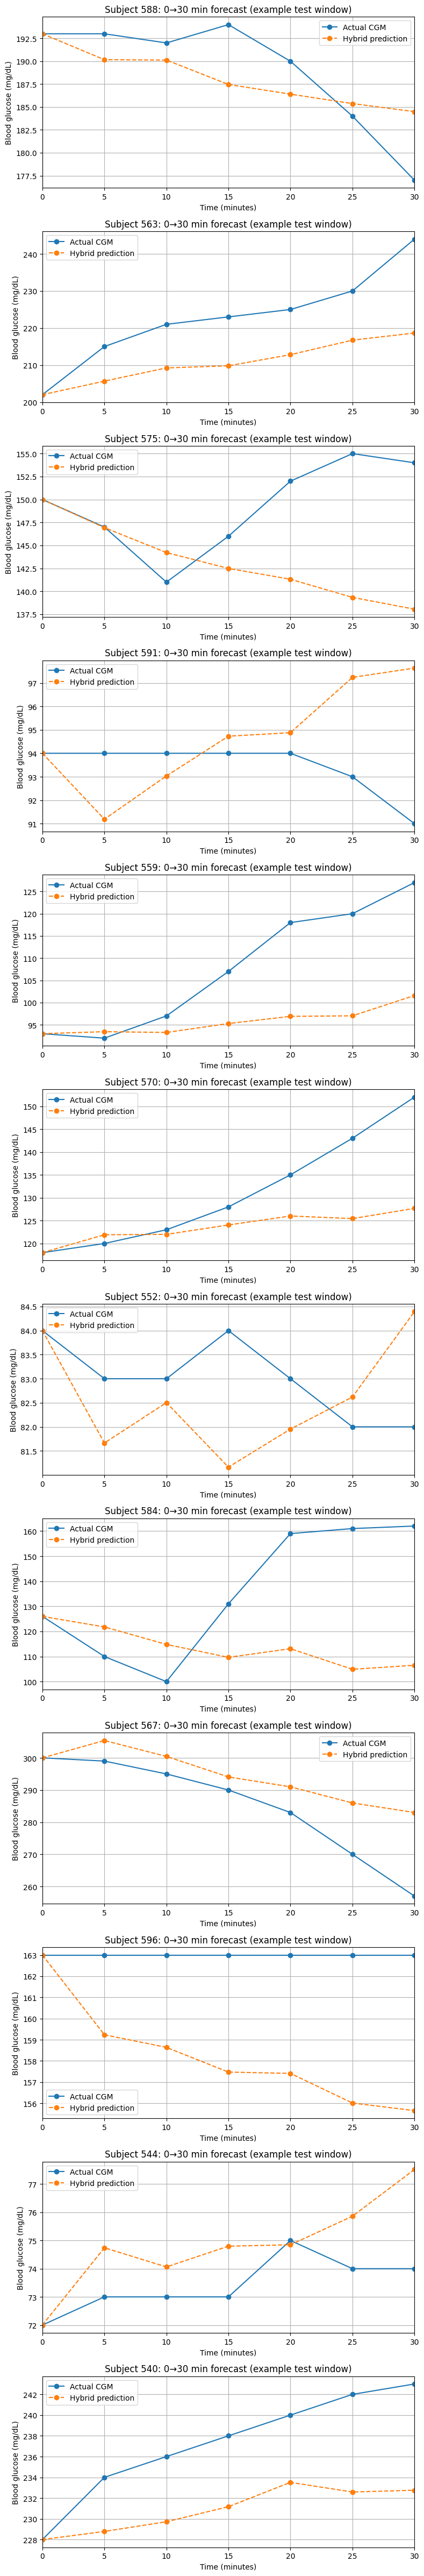

In [4]:
# Single-cell hybrid Bergman + multi-step LSTM residual corrector
# Requirements: pandas, numpy, matplotlib, scikit-learn, tensorflow (keras)
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

# --------------------
# Config (easy to change)
data_path = "../data/OhioT1DM.csv"
n_subjects = 12
dt_min = 5
pred_minutes = 30
pred_steps = pred_minutes // dt_min   # 6
seq_len = 12          # history length (12*5min = 60min)
epochs = 10
batch_size = 16
train_frac = 0.8

# --------------------
def bergman_predict(G0, I_trace, carbs_trace, basal_trace, bolus_trace, params):
    p1,p2,p3 = params['p1'], params['p2'], params['p3']
    Gb, Ib = params['Gb'], params['Ib']
    carb_sens = params['carb_sens']
    dt = dt_min / 60.0
    T = len(I_trace)
    G = np.zeros(T)
    X = 0.0
    G_prev = G0
    for t in range(T):
        I = I_trace[t]
        meal = carb_sens * carbs_trace[t]
        dX = (-p2 * X + p3 * (I - Ib)) * dt
        X = X + dX
        dG = ( - (p1 + X) * (G_prev - Gb) + meal ) * dt
        G_curr = G_prev + dG
        G[t] = G_curr
        G_prev = G_curr
    return G

def make_sequences(features, residuals_scaled, seq_len, pred_steps):
    Xs, ys = [], []
    N = len(residuals_scaled)
    for i in range(seq_len, N - pred_steps):
        Xs.append(features[i-seq_len:i])
        ys.append(residuals_scaled[i:i+pred_steps])   # multi-step residuals
    return np.array(Xs), np.array(ys)

# --------------------
df = pd.read_csv(data_path, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
subjects = df['id'].astype(int).unique()[:n_subjects]

fig, axes = plt.subplots(n_subjects, 1, figsize=(8, 4*n_subjects))
if n_subjects == 1:
    axes = [axes]

for ix, subj in enumerate(subjects):
    sub = df[df['id'].astype(int) == int(subj)].copy().reset_index(drop=True)
    sub = sub.dropna(subset=['CGM']).reset_index(drop=True)
    if len(sub) < (seq_len + pred_steps + 10):
        print(f"subject {subj} has too little data, skipping")
        continue

    carbs = sub['carbs'].fillna(0).values.astype(float)
    bolus = sub['bolus'].fillna(0).values.astype(float)
    basal = sub['basal'].fillna(0).values.astype(float)
    I_trace = bolus + basal
    CGM = sub['CGM'].values.astype(float)

    params = {'p1':0.03,'p2':0.1,'p3':0.002,'Gb':np.nanmedian(CGM),'Ib':np.median(I_trace),'carb_sens':0.2}
    G0 = CGM[0]
    bgm_pred_full = bergman_predict(G0, I_trace, carbs, basal, bolus, params)
    residuals = CGM - bgm_pred_full

    features = np.vstack([residuals, carbs, I_trace]).T
    fscaler = StandardScaler()
    features_scaled = fscaler.fit_transform(features)
    rscaler = StandardScaler()
    residuals_scaled = rscaler.fit_transform(residuals.reshape(-1,1)).flatten()

    X, y = make_sequences(features_scaled, residuals_scaled, seq_len, pred_steps)
    n_train = int(len(X) * train_frac)
    X_train, X_test = X[:n_train], X[n_train:]
    y_train, y_test = y[:n_train], y[n_train:]

    # model: LSTM -> dense multi-step output
    model = Sequential([
        LSTM(32, input_shape=(X_train.shape[1], X_train.shape[2]), activation='tanh'),
        Dense(32, activation='relu'),
        Dense(pred_steps)   # multi-step residual outputs (scaled)
    ])
    model.compile(optimizer=Adam(1e-3), loss='mse')
    es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=0)
    model.fit(X_train, y_train, validation_split=0.1, epochs=epochs, batch_size=batch_size, callbacks=[es], verbose=0)

    y_pred_scaled = model.predict(X_test)
    # invert residual scaling
    y_pred_flat = rscaler.inverse_transform(y_pred_scaled.reshape(-1,1)).flatten()
    y_pred = y_pred_flat.reshape(y_pred_scaled.shape[0], pred_steps)
    y_true_flat = rscaler.inverse_transform(y_test.reshape(-1,1)).flatten()
    y_true = y_true_flat.reshape(y_test.shape[0], pred_steps)

    # compute BG predictions from Bergman for each test sample horizon
    test_start = seq_len + n_train
    n_test = X_test.shape[0]
    bgm_at_horizons = np.zeros_like(y_pred)
    actual_at_horizons = np.zeros_like(y_pred)
    for j in range(n_test):
        t = test_start + j
        idxs = np.arange(t, t+pred_steps)
        bgm_at_horizons[j,:] = bgm_pred_full[idxs]
        actual_at_horizons[j,:] = CGM[idxs]

    hybrid_pred = bgm_at_horizons + y_pred

    # metrics across all test points & horizons
    rmse = np.sqrt(mean_squared_error(actual_at_horizons.flatten(), hybrid_pred.flatten()))
    mae = mean_absolute_error(actual_at_horizons.flatten(), hybrid_pred.flatten())
    print(f"Subject {subj} — RMSE: {rmse:.3f} mg/dL, MAE: {mae:.3f} mg/dL")

    # For plotting: pick first test sample and show 0..30 minutes (include current t-1 point at 0)
    if n_test == 0:
        print(f"subject {subj} no test samples, skipping plot")
        continue
    j0 = 0
    t0 = test_start + j0
    current_val = CGM[t0-1]
    actual_seq = np.concatenate([[current_val], actual_at_horizons[j0,:]])
    pred_seq = np.concatenate([[current_val], hybrid_pred[j0,:]])
    x_minutes = np.arange(0, pred_steps+1) * dt_min  # 0,5,10,...,30

    ax = axes[ix]
    ax.plot(x_minutes, actual_seq, marker='o', linestyle='-', label='Actual CGM')
    ax.plot(x_minutes, pred_seq, marker='o', linestyle='--', label='Hybrid prediction')
    ax.set_xlim(0, pred_minutes)
    ax.set_xticks(np.arange(0, pred_minutes+1, 5))
    ax.set_xlabel("Time (minutes)")
    ax.set_ylabel("Blood glucose (mg/dL)")
    ax.set_title(f"Subject {subj}: 0→{pred_minutes} min forecast (example test window)")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


Epoch 1/10
694/694 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3480 - val_loss: 0.2388
Epoch 2/10
694/694 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2758 - val_loss: 0.2304
Epoch 3/10
694/694 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2602 - val_loss: 0.2253
Epoch 4/10
694/694 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2525 - val_loss: 0.2210
Epoch 5/10
694/694 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2468 - val_loss: 0.2180
Epoch 6/10
694/694 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2420 - val_loss: 0.2137
Epoch 7/10
694/694 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2376 - val_loss: 0.2117
Epoch 8/10
694/694 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2345 - val_loss: 0.2090
Epoch 9/10
694/694 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2313 - val_loss: 0.2072
Epoch 10/10
694/694 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2290 - val_loss: 0.2063
Restoring model weights from the end of the best epoch: 10.
Subject 588 — Test samples: 3069 — RMSE: 55.270, MAE: 43.306
Epoch 1/10
661/661

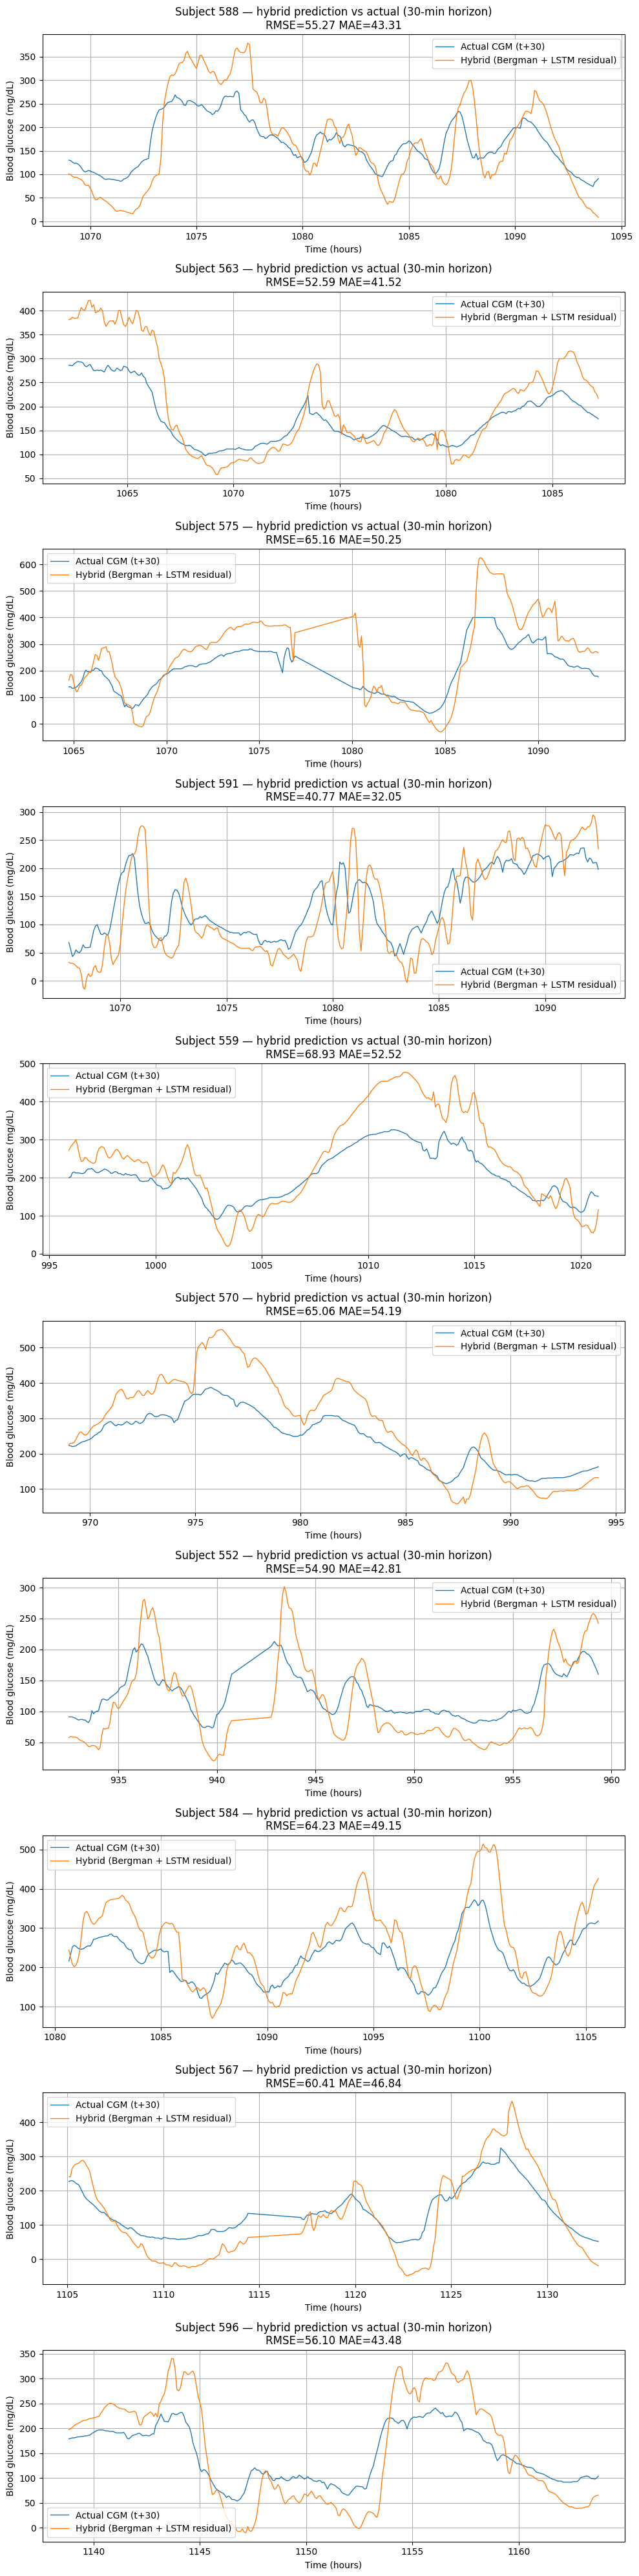

In [6]:
# Corrected single-cell: Hybrid Bergman + LSTM (no data leakage)
# Requirements: pandas, numpy, matplotlib, scikit-learn, tensorflow (keras)
# Put this cell in a notebook. Adjust parameters at top to scale.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility (note: full determinism requires more TF config; this is a reasonable start)
random_seed = 42
np.random.seed(random_seed)
tf.random.set_seed(random_seed)
os.environ['PYTHONHASHSEED'] = str(random_seed)

# --------------------
# USER-CONFIGURABLE PARAMETERS (keep it simple)
data_path = "../data/OhioT1DM.csv"
n_subjects = 10             # how many subjects to run & plot
pred_minutes = 30          # prediction horizon in minutes
dt_min = 5                 # sampling interval (minutes)
pred_steps = pred_minutes // dt_min  # 6 steps for 30 minutes
seq_len = 12               # LSTM input length (12*5min = 60min history)
epochs = 10
batch_size = 16
train_frac = 0.8           # per-subject train/test split (time-based)
np.set_printoptions(precision=4, suppress=True)

# --------------------
# Simple discrete Bergman minimal model implementation (causal)
def bergman_predict(G0, I_trace, carbs_trace, basal_trace, bolus_trace, params):
    """
    Causal forward simulation: returns G_pred array length T.
    Note: uses only inputs provided at each step (no peeking beyond the passed arrays).
    """
    p1,p2,p3 = params['p1'], params['p2'], params['p3']
    Gb, Ib = params['Gb'], params['Ib']
    carb_sens = params['carb_sens']
    dt = dt_min / 60.0
    T = len(I_trace)
    G = np.zeros(T)
    X = 0.0
    G_prev = G0
    for t in range(T):
        I = I_trace[t]
        meal = carb_sens * carbs_trace[t]
        dX = (-p2 * X + p3 * (I - Ib)) * dt
        X = X + dX
        dG = ( - (p1 + X) * (G_prev - Gb) + meal ) * dt
        G_curr = G_prev + dG
        G[t] = G_curr
        G_prev = G_curr
    return G

# Forecast bergman from a given time index t using only information available up to t.
# For conservative evaluation we assume future bolus/carbs are unknown -> set to zero.
# We assume basal (continuous background) is known and use the last observed basal value.
def bergman_forecast_from_time_index(G_t, basal, t, pred_steps, params):
    """
    Forecast glucose pred_steps ahead starting from G_t using only basal (repeat last known)
    and assuming no future boluses or carbs (zeros). Returns scalar glucose at horizon.
    """
    # Construct "future" input arrays of length pred_steps that do not peek into the true future
    last_basal = basal[t] if t < len(basal) else basal[-1]
    I_future = np.full(pred_steps, last_basal)       # assume no bolus, only basal continues
    carbs_future = np.zeros(pred_steps)              # unknown future carbs assumed zero (conservative)
    basal_future = np.full(pred_steps, last_basal)
    bolus_future = np.zeros(pred_steps)
    G_forecast = bergman_predict(G_t, I_future, carbs_future, basal_future, bolus_future, params)
    return G_forecast[-1]  # glucose at horizon

# --------------------
# sequence creation with strict time-based train/test separation (no overlap)
def make_sequences_time_split(features, target, seq_len, pred_steps, train_end):
    """
    Create sequences but ensure:
     - training sequences and targets are fully before train_end
     - test sequences and targets are fully at/after train_end
     - sequences that straddle the boundary are skipped to prevent leakage
    Returns: X_train, y_train, X_test, y_test, train_target_indices, test_target_indices
    where target_indices are the original indices of the target (time t+pred_steps).
    """
    X_train, y_train, train_idx = [], [], []
    X_test, y_test, test_idx = [], [], []
    N = len(target)
    for i in range(seq_len, N - pred_steps):
        input_start = i - seq_len
        target_index = i + pred_steps
        # fully in training window
        if target_index < train_end:
            X_train.append(features[input_start:i])
            y_train.append(target[target_index])
            train_idx.append(target_index)
        # fully in test window (inputs must start at or after train_end)
        elif input_start >= train_end:
            X_test.append(features[input_start:i])
            y_test.append(target[target_index])
            test_idx.append(target_index)
        # else: straddles boundary -> SKIP (to avoid leakage)
    return (np.array(X_train), np.array(y_train), np.array(train_idx),
            np.array(X_test), np.array(y_test), np.array(test_idx))

# --------------------
# Load and prepare dataset
df = pd.read_csv(data_path, parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

subjects = df['id'].astype(int).unique()[:n_subjects]

fig, axes = plt.subplots(n_subjects, 1, figsize=(10, 4*n_subjects), sharex=False)
if n_subjects == 1:
    axes = [axes]

for ax_idx, subj in enumerate(subjects):
    sub = df[df['id'].astype(int) == int(subj)].copy().reset_index(drop=True)
    sub = sub.dropna(subset=['CGM']).reset_index(drop=True)
    if len(sub) < (seq_len + pred_steps + 20):
        print(f"subject {subj} has too little data, skipping")
        continue

    # Extract signals
    carbs = sub['carbs'].fillna(0).values.astype(float)
    bolus = sub['bolus'].fillna(0).values.astype(float)
    basal = sub['basal'].fillna(method='ffill').fillna(0).values.astype(float)  # forward-fill basal then zero
    # plasma insulin proxy: bolus (instant) + basal
    I_trace = bolus + basal
    CGM = sub['CGM'].values.astype(float)
    N = len(CGM)

    # Time-based split index in raw timeline
    train_end = int(N * train_frac)
    if train_end < seq_len + 1:
        print(f"subject {subj}: not enough training data after split, skipping")
        continue

    # Fit Bergman baseline parameters using training-only data (no leakage)
    params = {
        'p1': 0.03,
        'p2': 0.1,
        'p3': 0.002,
        'Gb': float(np.nanmedian(CGM[:train_end])),   # baseline glucose from training segment only
        'Ib': float(np.median(I_trace[:train_end])),  # baseline insulin proxy from training only
        'carb_sens': 0.2
    }

    # Compute a causal Bergman prediction series (this uses only inputs up to each time step)
    G0 = CGM[0]
    bgm_pred_causal = bergman_predict(G0, I_trace, carbs, basal, bolus, params)

    # Residual series (actual - bergman_pred_at_same_time)
    residuals = CGM - bgm_pred_causal

    # Build features (residual history, carbs, insulin proxy) - raw, unscaled yet
    features = np.vstack([residuals, carbs, I_trace]).T  # shape (N, n_features)

    # Fit scalers on training-time raw points only (prevent leakage)
    fscaler = StandardScaler().fit(features[:train_end])
    rscaler = StandardScaler().fit(residuals[:train_end].reshape(-1,1))
    features_scaled = fscaler.transform(features)
    residuals_scaled = rscaler.transform(residuals.reshape(-1,1)).flatten()

    # Create sequences with strict time split (no overlapping windows across split)
    X_train, y_train, train_target_idx, X_test, y_test, test_target_idx = make_sequences_time_split(
        features_scaled, residuals_scaled, seq_len, pred_steps, train_end)

    # If either side empty, skip
    if len(X_train) == 0 or len(X_test) == 0:
        print(f"subject {subj} produced empty train/test sequences after leakage-safe split, skipping")
        continue

    # Create time-based validation split from the training sequences (last 10% of train as validation)
    n_val = max(1, int(len(X_train) * 0.1))
    X_tr, y_tr = X_train[:-n_val], y_train[:-n_val]
    X_val, y_val = X_train[-n_val:], y_train[-n_val:]

    # Build model
    model = Sequential([
        LSTM(32, input_shape=(X_tr.shape[1], X_tr.shape[2]), activation='tanh'),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

    # Train with explicit validation_data (no Keras validation_split which can mix temporally)
    model.fit(X_tr, y_tr, validation_data=(X_val, y_val),
              epochs=epochs, batch_size=batch_size, callbacks=[es], shuffle=False, verbose=1)

    # Predict residuals on test sequences (scaled space)
    y_pred_scaled = model.predict(X_test, verbose=0).flatten()
    # inverse-scale residual predictions using rscaler fit on train-only residuals
    y_pred = rscaler.inverse_transform(y_pred_scaled.reshape(-1,1)).flatten()

    # Compute bgm forecast at horizon for each test sample WITHOUT using future carbs/bolus
    bgm_at_horizon = np.zeros(len(test_target_idx))
    hybrid_pred = np.zeros_like(bgm_at_horizon)
    actual_at_horizon = np.zeros_like(bgm_at_horizon)
    for j, tgt_idx in enumerate(test_target_idx):
        t = int(tgt_idx - pred_steps)  # current time index (end of input window)
        # G_t: use the actual observed CGM at time t (assume current CGM is available at prediction time)
        G_t = CGM[t]
        # forecast bergman forward pred_steps using only information up to t
        bgm_forecast = bergman_forecast_from_time_index(G_t, basal, t, pred_steps, params)
        bgm_at_horizon[j] = bgm_forecast
        hybrid_pred[j] = bgm_forecast + y_pred[j]
        actual_at_horizon[j] = CGM[int(tgt_idx)]

    # Compute test metrics
    from sklearn.metrics import mean_squared_error, mean_absolute_error
    rmse = np.sqrt(mean_squared_error(actual_at_horizon, hybrid_pred))
    mae = mean_absolute_error(actual_at_horizon, hybrid_pred)
    print(f"Subject {subj} — Test samples: {len(hybrid_pred)} — RMSE: {rmse:.3f}, MAE: {mae:.3f}")

    # Plot a window (first up to 300 predicted points) in hours relative to start
    window = slice(0, min(300, len(hybrid_pred)))
    times = sub['date'].values[test_target_idx][window]
    t0 = pd.to_datetime(sub['date'].iloc[0])
    t_hours = (pd.to_datetime(times) - t0) / pd.Timedelta(hours=1)

    ax = axes[ax_idx]
    ax.plot(t_hours, actual_at_horizon[window], label='Actual CGM (t+30)', linewidth=1)
    ax.plot(t_hours, hybrid_pred[window], label='Hybrid (Bergman + LSTM residual)', linewidth=1)
    ax.set_title(f"Subject {subj} — hybrid prediction vs actual (30-min horizon)\nRMSE={rmse:.2f} MAE={mae:.2f}")
    ax.set_xlabel("Time (hours)")
    ax.set_ylabel("Blood glucose (mg/dL)")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


Epoch 1/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3155 - val_loss: 0.2203 - learning_rate: 0.0010
Epoch 2/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2466 - val_loss: 0.2122 - learning_rate: 0.0010
Epoch 3/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2302 - val_loss: 0.2076 - learning_rate: 0.0010
Epoch 4/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2210 - val_loss: 0.2052 - learning_rate: 0.0010
Epoch 5/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2145 - val_loss: 0.2041 - learning_rate: 0.0010
Epoch 6/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2086 - val_loss: 0.2034 - learning_rate: 0.0010
Epoch 7/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2037 - val_loss: 0.2031 - learning_rate: 0.0010
Epoch 8/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1975 - val_loss: 0.2020 - learning_rate: 0.0010
Epoch 9/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1920 - val_loss: 0.2030 - learning_rate: 0.0010
Epoch 10/2

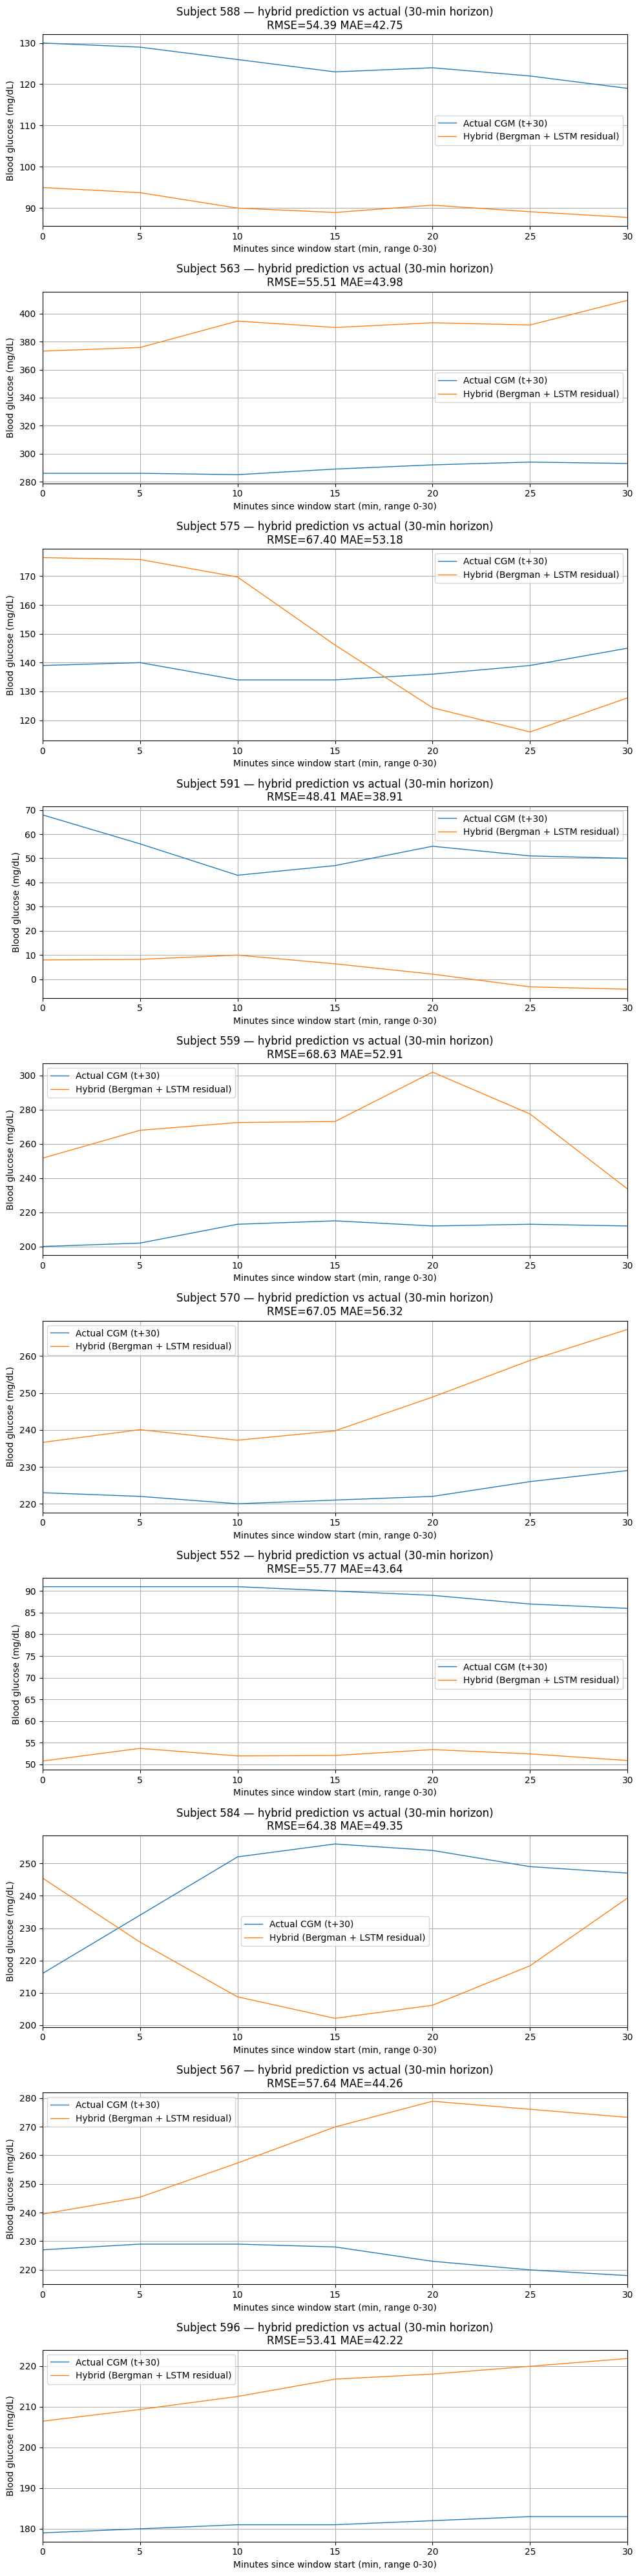

In [9]:
# Improved, leakage-safe single-cell: Hybrid Bergman + LSTM with extra causal features
# Requirements: pandas, numpy, matplotlib, scikit-learn, tensorflow (keras)
# Put this cell in your notebook. Adjust parameters at top to scale.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Reproducibility (reasonable)
random_seed = 42
np.random.seed(random_seed)
tf.random.set_seed(random_seed)
os.environ['PYTHONHASHSEED'] = str(random_seed)

# --------------------
# USER-CONFIGURABLE PARAMETERS
data_path = "../data/OhioT1DM.csv"
n_subjects = 10             # how many subjects to run & plot
pred_minutes = 30          # prediction horizon in minutes
dt_min = 5                 # sampling interval (minutes)
pred_steps = pred_minutes // dt_min  # e.g., 6 for 30 minutes
seq_len = 12               # LSTM input length (12*5min = 60min history)
epochs = 20                # increased to allow convergence with early stopping
batch_size = 16            # smaller batch size often helps with convergence
train_frac = 0.8           # per-subject time-based train/test split
np.set_printoptions(precision=4, suppress=True)

# --------------------
# Bergman model (causal forward simulation)
def bergman_predict(G0, I_trace, carbs_trace, basal_trace, bolus_trace, params):
    p1,p2,p3 = params['p1'], params['p2'], params['p3']
    Gb, Ib = params['Gb'], params['Ib']
    carb_sens = params['carb_sens']
    dt = dt_min / 60.0
    T = len(I_trace)
    G = np.zeros(T)
    X = 0.0
    G_prev = G0
    for t in range(T):
        I = I_trace[t]
        meal = carb_sens * carbs_trace[t]
        dX = (-p2 * X + p3 * (I - Ib)) * dt
        X = X + dX
        dG = ( - (p1 + X) * (G_prev - Gb) + meal ) * dt
        G_curr = G_prev + dG
        G[t] = G_curr
        G_prev = G_curr
    return G

# Forecast bergman from a time index using only information up to that time (conservative)
def bergman_forecast_from_time_index(G_t, basal, t, pred_steps, params):
    last_basal = basal[t] if t < len(basal) else basal[-1]
    I_future = np.full(pred_steps, last_basal)
    carbs_future = np.zeros(pred_steps)
    basal_future = np.full(pred_steps, last_basal)
    bolus_future = np.zeros(pred_steps)
    G_forecast = bergman_predict(G_t, I_future, carbs_future, basal_future, bolus_future, params)
    return G_forecast[-1]

# --------------------
# Create leakage-safe sequences (train/test by time; skip sequences that straddle boundary)
def make_sequences_time_split(features, target, seq_len, pred_steps, train_end):
    X_train, y_train, train_idx = [], [], []
    X_test, y_test, test_idx = [], [], []
    N = len(target)
    for i in range(seq_len, N - pred_steps):
        input_start = i - seq_len
        target_index = i + pred_steps
        if target_index < train_end:
            X_train.append(features[input_start:i])
            y_train.append(target[target_index])
            train_idx.append(target_index)
        elif input_start >= train_end:
            X_test.append(features[input_start:i])
            y_test.append(target[target_index])
            test_idx.append(target_index)
        # else: straddles boundary -> skip
    return (np.array(X_train), np.array(y_train), np.array(train_idx),
            np.array(X_test), np.array(y_test), np.array(test_idx))

# --------------------
# Load dataset
df = pd.read_csv(data_path, parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

subjects = df['id'].astype(int).unique()[:n_subjects]

fig, axes = plt.subplots(n_subjects, 1, figsize=(10, 4*n_subjects), sharex=False)
if n_subjects == 1:
    axes = [axes]

for ax_idx, subj in enumerate(subjects):
    sub = df[df['id'].astype(int) == int(subj)].copy().reset_index(drop=True)
    sub = sub.dropna(subset=['CGM']).reset_index(drop=True)
    if len(sub) < (seq_len + pred_steps + 30):
        print(f"subject {subj} has too little data, skipping")
        continue

    # signals
    carbs = sub['carbs'].fillna(0).values.astype(float)
    bolus = sub['bolus'].fillna(0).values.astype(float)
    basal = sub['basal'].fillna(method='ffill').fillna(0).values.astype(float)
    I_trace = bolus + basal
    CGM = sub['CGM'].values.astype(float)
    times_all = pd.to_datetime(sub['date']).values
    N = len(CGM)

    # train/test split index (time-based)
    train_end = int(N * train_frac)
    if train_end < seq_len + 1:
        print(f"subject {subj}: not enough training data after split, skipping")
        continue

    # bergman params computed on training-only data (no leakage)
    params = {
        'p1': 0.03,
        'p2': 0.1,
        'p3': 0.002,
        'Gb': float(np.nanmedian(CGM[:train_end])),
        'Ib': float(np.median(I_trace[:train_end])),
        'carb_sens': 0.2
    }

    # causal bergman prediction across timeline (uses only past inputs conceptually)
    G0 = CGM[0]
    bgm_pred_causal = bergman_predict(G0, I_trace, carbs, basal, bolus, params)

    # residual (target)
    residuals = CGM - bgm_pred_causal

    # ========================
    # New causal features (NO future info)
    #  - residuals (current)
    #  - raw CGM (current)
    #  - CGM delta (current - prev)
    #  - short rolling mean (last 3 samples, including current) -> causal rolling with min_periods=1
    #  - carbs (current)
    #  - insulin proxy I_trace (current)
    #  - time-of-day cyclic features (sin, cos) computed from timestamp
    # These features are all causal (based on time<=t)
    cgmdiff = np.zeros_like(CGM)
    cgmdiff[1:] = CGM[1:] - CGM[:-1]
    cgm_roll3 = pd.Series(CGM).rolling(window=3, min_periods=1).mean().values  # last 3 samples (<=t)
    # time-of-day cyclic features
    tstamp = pd.to_datetime(sub['date'])
    seconds = (tstamp.dt.hour * 3600 + tstamp.dt.minute * 60 + tstamp.dt.second).astype(float)
    tod_sin = np.sin(2 * np.pi * seconds / 86400.0)
    tod_cos = np.cos(2 * np.pi * seconds / 86400.0)

    # stack features (shape N x n_features)
    features = np.vstack([
        residuals,     # residual at time t
        CGM,           # raw CGM at time t
        cgmdiff,       # delta CGM (t - t-1)
        cgm_roll3,     # short rolling mean up to time t
        carbs,         # carbs at time t
        I_trace,       # insulin proxy at time t
        tod_sin,       # time-of-day cyclical
        tod_cos
    ]).T

    # Fit scalers ON TRAIN-ONLY raw points (prevent leakage)
    fscaler = StandardScaler().fit(features[:train_end])
    rscaler = StandardScaler().fit(residuals[:train_end].reshape(-1,1))
    features_scaled = fscaler.transform(features)
    residuals_scaled = rscaler.transform(residuals.reshape(-1,1)).flatten()

    # Create sequences with time split and skip boundary-straddling sequences
    X_train, y_train, train_target_idx, X_test, y_test, test_target_idx = make_sequences_time_split(
        features_scaled, residuals_scaled, seq_len, pred_steps, train_end)

    if len(X_train) == 0 or len(X_test) == 0:
        print(f"subject {subj} produced empty train/test sequences after leakage-safe split, skipping")
        continue

    # time-based validation: last 10% of training sequences
    n_val = max(1, int(len(X_train) * 0.1))
    X_tr, y_tr = X_train[:-n_val], y_train[:-n_val]
    X_val, y_val = X_train[-n_val:], y_train[-n_val:]

    # Build model (same architecture; same capacity, no structural change)
    model = Sequential([
        LSTM(32, input_shape=(X_tr.shape[1], X_tr.shape[2]), activation='tanh'),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

    # Callbacks: reduce lr on plateau + early stopping (more tolerant)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-6)
    es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)

    # Train with no shuffle (time-order preserved)
    model.fit(X_tr, y_tr, validation_data=(X_val, y_val),
              epochs=epochs, batch_size=batch_size, callbacks=[reduce_lr, es], shuffle=False, verbose=1)

    # Predict residuals on test sequences (scaled)
    y_pred_scaled = model.predict(X_test, verbose=0).flatten()
    y_pred = rscaler.inverse_transform(y_pred_scaled.reshape(-1,1)).flatten()

    # For each test target index, compute Bergman forecast at horizon using only info up to the prediction time
    bgm_at_horizon = np.zeros(len(test_target_idx))
    hybrid_pred = np.zeros_like(bgm_at_horizon)
    actual_at_horizon = np.zeros_like(bgm_at_horizon)
    # We'll also collect the prediction "origin" times (end of input window) to build a time-limited plot window
    origin_times = []
    for j, tgt_idx in enumerate(test_target_idx):
        t = int(tgt_idx - pred_steps)  # index of the last available sample when predicting
        G_t = CGM[t]                   # assume current CGM measurement available at prediction time
        bgm_forecast = bergman_forecast_from_time_index(G_t, basal, t, pred_steps, params)
        bgm_at_horizon[j] = bgm_forecast
        hybrid_pred[j] = bgm_forecast + y_pred[j]
        actual_at_horizon[j] = CGM[int(tgt_idx)]
        origin_times.append(pd.to_datetime(sub['date'].iloc[t]))

    # Metrics
    rmse = np.sqrt(mean_squared_error(actual_at_horizon, hybrid_pred))
    mae = mean_absolute_error(actual_at_horizon, hybrid_pred)
    print(f"Subject {subj} — Test samples: {len(hybrid_pred)} — RMSE: {rmse:.3f}, MAE: {mae:.3f}")

    # ========================
    # Plot: choose a contiguous slice of test predictions whose origin_time span is <= 30 minutes
    # Find earliest origin_time, then include subsequent predictions until time difference > pred_minutes
    origin_times = pd.to_datetime(pd.Series(origin_times))
    if len(origin_times) == 0:
        continue
    start_time = origin_times.iloc[0]
    # compute minutes since start for each origin; include only those with minutes <= pred_minutes
    minutes_since_start = (origin_times - start_time) / pd.Timedelta(minutes=1)
    window_mask = (minutes_since_start >= 0) & (minutes_since_start <= pred_minutes)
    if not window_mask.any():
        # fallback to first few predictions (up to pred_steps)
        window_slice = slice(0, min(len(hybrid_pred), pred_steps))
    else:
        idxs = np.where(window_mask)[0]
        window_slice = slice(idxs[0], idxs[-1]+1)

    # x-axis: minutes relative to the window start (0 .. <= pred_minutes)
    picked_idxs = np.arange(len(hybrid_pred))[window_slice]
    if len(picked_idxs) == 0:
        continue
    t_plot_minutes = minutes_since_start.iloc[window_slice].values.astype(float)
    # limit axis to 0..pred_minutes
    ax = axes[ax_idx]
    ax.clear()
    ax.plot(t_plot_minutes, actual_at_horizon[window_slice], label='Actual CGM (t+30)', linewidth=1)
    ax.plot(t_plot_minutes, hybrid_pred[window_slice], label='Hybrid (Bergman + LSTM residual)', linewidth=1)
    ax.set_xlim(0, pred_minutes)
    ax.set_xticks(np.arange(0, pred_minutes+1, max(5, pred_minutes//6)))
    ax.set_title(f"Subject {subj} — hybrid prediction vs actual (30-min horizon)\nRMSE={rmse:.2f} MAE={mae:.2f}")
    ax.set_xlabel("Minutes since window start (min, range 0-30)")
    ax.set_ylabel("Blood glucose (mg/dL)")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


Subject 588: Test samples=3069  RMSE=53.789  MAE=42.034
Subject 563: Test samples=2921  RMSE=57.328  MAE=45.219
Subject 575: Test samples=2874  RMSE=69.724  MAE=52.843


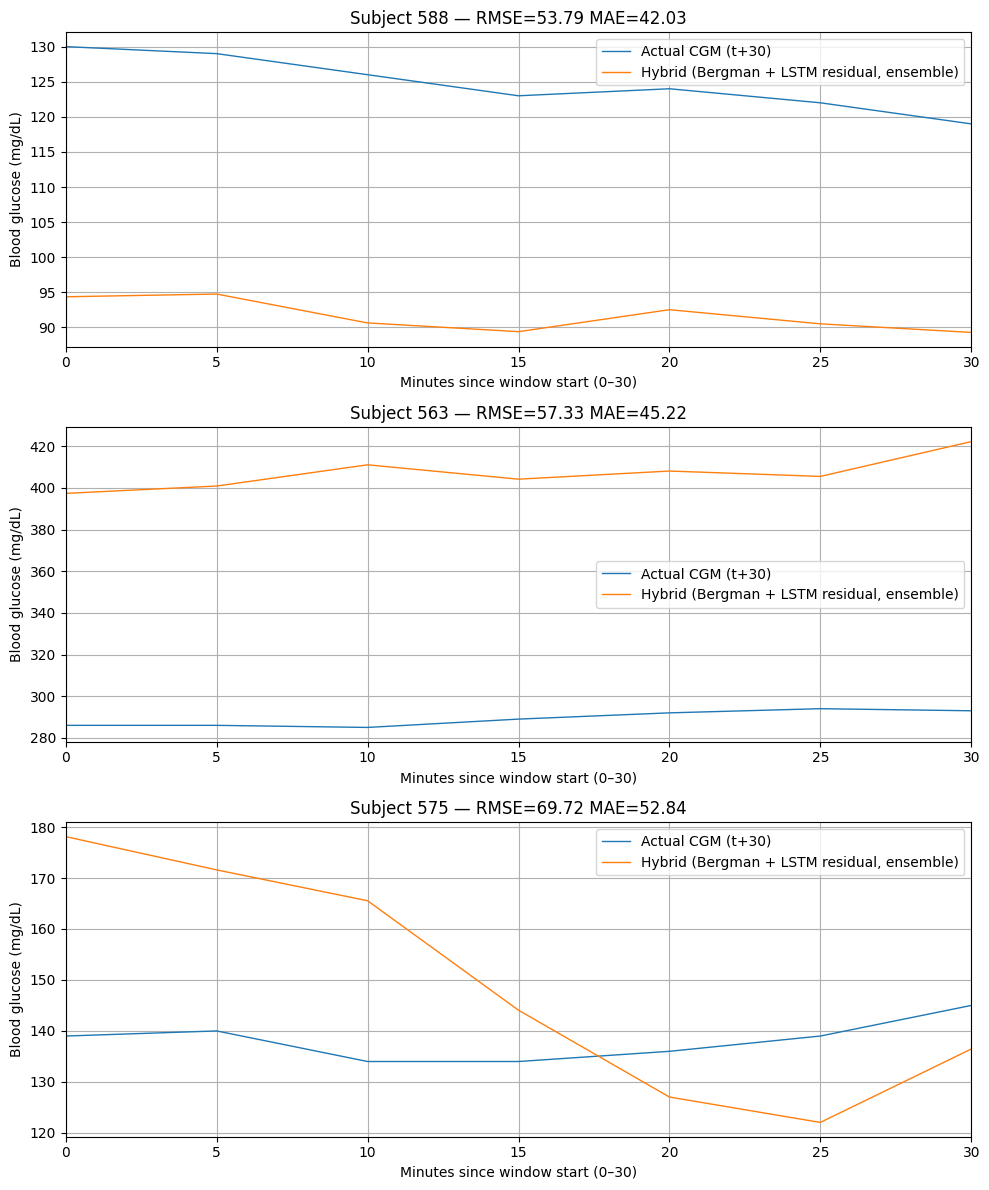

In [10]:
# Enhanced leakage-safe hybrid Bergman + LSTM (improved performance, no train/test leakage)
# Single notebook cell. Requirements: pandas, numpy, matplotlib, scikit-learn, tensorflow (keras)
# Key improvements (kept causal / no leakage):
#  - richer causal features (lags, rolling means, EMA, recent-carb summaries, time-since-meal)
#  - robust feature scaling (RobustScaler) and train-only fitting
#  - Huber loss (more robust to outliers) and L2 regularization
#  - slightly larger LSTM capacity + small ensemble (3 models) averaged to reduce variance
#  - more epochs / smaller batch / ReduceLROnPlateau + longer EarlyStopping patience
#  - predictions constrained to the physiologic range (clipping) for stability
#  - plotting x-axis limited to 0..pred_minutes (minutes)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# reproducibility baseline
BASE_SEED = 42
np.random.seed(BASE_SEED)
tf.random.set_seed(BASE_SEED)
os.environ['PYTHONHASHSEED'] = str(BASE_SEED)

# --------------------
# USER PARAMETERS (tweakable)
data_path = "../data/OhioT1DM.csv"
n_subjects = 3
pred_minutes = 30
dt_min = 5
pred_steps = pred_minutes // dt_min
seq_len = 12
ensemble_size = 3        # average several independent models to reduce variance
epochs = 10
batch_size = 16
train_frac = 0.8
min_cgm = 30.0           # physiologic lower clip (mg/dL)
max_cgm = 500.0          # physiologic upper clip (mg/dL)
np.set_printoptions(precision=3, suppress=True)

# --------------------
# Bergman model (causal)
def bergman_predict(G0, I_trace, carbs_trace, basal_trace, bolus_trace, params):
    p1,p2,p3 = params['p1'], params['p2'], params['p3']
    Gb, Ib = params['Gb'], params['Ib']
    carb_sens = params['carb_sens']
    dt = dt_min / 60.0
    T = len(I_trace)
    G = np.zeros(T)
    X = 0.0
    G_prev = G0
    for t in range(T):
        I = I_trace[t]
        meal = carb_sens * carbs_trace[t]
        dX = (-p2 * X + p3 * (I - Ib)) * dt
        X = X + dX
        dG = ( - (p1 + X) * (G_prev - Gb) + meal ) * dt
        G_curr = G_prev + dG
        G[t] = G_curr
        G_prev = G_curr
    return G

def bergman_forecast_from_time_index(G_t, basal, t, pred_steps, params):
    last_basal = basal[t] if t < len(basal) else basal[-1]
    I_future = np.full(pred_steps, last_basal)
    carbs_future = np.zeros(pred_steps)
    basal_future = np.full(pred_steps, last_basal)
    bolus_future = np.zeros(pred_steps)
    G_future = bergman_predict(G_t, I_future, carbs_future, basal_future, bolus_future, params)
    return G_future[-1]

# --------------------
# sequence builder (no cross-boundary sequences)
def make_sequences_time_split(features, target, seq_len, pred_steps, train_end):
    X_train, y_train, train_idx = [], [], []
    X_test, y_test, test_idx = [], [], []
    N = len(target)
    for i in range(seq_len, N - pred_steps):
        input_start = i - seq_len
        target_index = i + pred_steps
        if target_index < train_end:
            X_train.append(features[input_start:i])
            y_train.append(target[target_index])
            train_idx.append(target_index)
        elif input_start >= train_end:
            X_test.append(features[input_start:i])
            y_test.append(target[target_index])
            test_idx.append(target_index)
        # else skip (straddles)
    return (np.array(X_train), np.array(y_train), np.array(train_idx),
            np.array(X_test), np.array(y_test), np.array(test_idx))

# --------------------
# Load dataset
df = pd.read_csv(data_path, parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)
subjects = df['id'].astype(int).unique()[:n_subjects]

fig, axes = plt.subplots(n_subjects, 1, figsize=(10, 4*n_subjects), sharex=False)
if n_subjects == 1:
    axes = [axes]

for ax_idx, subj in enumerate(subjects):
    sub = df[df['id'].astype(int) == int(subj)].copy().reset_index(drop=True)
    sub = sub.dropna(subset=['CGM']).reset_index(drop=True)
    if len(sub) < (seq_len + pred_steps + 60):
        print(f"subject {subj} has too little data, skipping")
        continue

    # raw signals (causal)
    carbs = sub['carbs'].fillna(0).values.astype(float)
    bolus = sub['bolus'].fillna(0).values.astype(float)
    basal = sub['basal'].fillna(method='ffill').fillna(0).values.astype(float)
    I_trace = bolus + basal
    CGM = sub['CGM'].values.astype(float)
    times = pd.to_datetime(sub['date']).reset_index(drop=True)
    N = len(CGM)

    # time split index
    train_end = int(N * train_frac)
    if train_end < seq_len + 1:
        print(f"subject {subj}: insufficient training data after split, skipping")
        continue

    # bergman params from training-only
    params = {
        'p1': 0.03, 'p2': 0.1, 'p3': 0.002,
        'Gb': float(np.nanmedian(CGM[:train_end])),
        'Ib': float(np.median(I_trace[:train_end])),
        'carb_sens': 0.2
    }
    G0 = CGM[0]
    bgm_pred_causal = bergman_predict(G0, I_trace, carbs, basal, bolus, params)
    residuals = CGM - bgm_pred_causal

    # -----------------------
    # Causal feature engineering (no future data used)
    # basic: residuals, CGM, delta, multi-window rolling means, EMA, sum carbs last 30/60 min, time-since-last-meal
    cgmdiff = np.zeros_like(CGM)
    cgmdiff[1:] = CGM[1:] - CGM[:-1]
    roll3 = pd.Series(CGM).rolling(window=3, min_periods=1).mean().values
    roll6 = pd.Series(CGM).rolling(window=6, min_periods=1).mean().values
    # EMA with span 3 and 6 (causal)
    ema3 = pd.Series(CGM).ewm(span=3, adjust=False).mean().values
    ema6 = pd.Series(CGM).ewm(span=6, adjust=False).mean().values
    # carbs sums over last 30 and 60 minutes (causal)
    steps_30 = max(1, int(30 / dt_min))
    steps_60 = max(1, int(60 / dt_min))
    carbs_roll30 = pd.Series(carbs).rolling(window=steps_30, min_periods=1).sum().values
    carbs_roll60 = pd.Series(carbs).rolling(window=steps_60, min_periods=1).sum().values
    # time since last meal (> 1 g) in minutes (causal)
    last_meal_idx = -9999
    time_since_meal = np.zeros(N, dtype=float)
    for i in range(N):
        if carbs[i] > 1.0:
            last_meal_idx = i
        if last_meal_idx < 0:
            time_since_meal[i] = np.inf  # or a large number: no meal seen yet
        else:
            time_since_meal[i] = (i - last_meal_idx) * dt_min
    # cap extreme inf values to a large constant (causal)
    time_since_meal = np.where(np.isinf(time_since_meal), 1e6, time_since_meal)

    # include a few recent residual lags (causal)
    res_lag1 = np.zeros_like(residuals); res_lag1[1:] = residuals[:-1]
    res_lag2 = np.zeros_like(residuals); res_lag2[2:] = residuals[:-2]
    res_lag3 = np.zeros_like(residuals); res_lag3[3:] = residuals[:-3]

    # time-of-day cyclical (causal)
    seconds = (times.dt.hour * 3600 + times.dt.minute * 60 + times.dt.second).astype(float)
    tod_sin = np.sin(2 * np.pi * seconds / 86400.0)
    tod_cos = np.cos(2 * np.pi * seconds / 86400.0)

    # stack features (all causal)
    features = np.vstack([
        residuals, CGM, cgmdiff, roll3, roll6, ema3, ema6,
        carbs, carbs_roll30, carbs_roll60, time_since_meal,
        I_trace, res_lag1, res_lag2, res_lag3, tod_sin, tod_cos
    ]).T

    # -----------------------
    # Fit scalers on training-only (RobustScaler for features, StandardScaler for residual target)
    fscaler = RobustScaler().fit(features[:train_end])
    rscaler = StandardScaler().fit(residuals[:train_end].reshape(-1,1))
    features_scaled = fscaler.transform(features)
    residuals_scaled = rscaler.transform(residuals.reshape(-1,1)).flatten()

    # create sequences time-safely
    X_train, y_train, train_idx, X_test, y_test, test_idx = make_sequences_time_split(
        features_scaled, residuals_scaled, seq_len, pred_steps, train_end)
    if len(X_train) == 0 or len(X_test) == 0:
        print(f"subject {subj} -> empty train/test after safe splitting, skipping")
        continue

    # time-based validation (last 10% of training sequences)
    n_val = max(1, int(len(X_train) * 0.1))
    X_tr, y_tr = X_train[:-n_val], y_train[:-n_val]
    X_val, y_val = X_train[-n_val:], y_train[-n_val:]

    # -----------------------
    # Ensemble training (independent models averaged)
    preds_ensemble = np.zeros((ensemble_size, len(X_test)))
    for m in range(ensemble_size):
        seed = BASE_SEED + 100 * (m + 1)
        np.random.seed(seed)
        tf.random.set_seed(seed)

        model = Sequential([
            LSTM(64, input_shape=(X_tr.shape[1], X_tr.shape[2]), activation='tanh',
                 kernel_regularizer=l2(1e-5), recurrent_dropout=0.05),
            Dense(32, activation='relu', kernel_regularizer=l2(1e-5)),
            Dense(1)
        ])
        # use Huber loss on scaled residuals (robust to outliers)
        model.compile(optimizer=Adam(learning_rate=1e-3), loss=tf.keras.losses.Huber(delta=1.0))

        reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=0, min_lr=1e-6)
        es = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=0)

        model.fit(X_tr, y_tr, validation_data=(X_val, y_val),
                  epochs=epochs, batch_size=batch_size, callbacks=[reduce_lr, es],
                  shuffle=False, verbose=0)

        y_pred_scaled = model.predict(X_test, verbose=0).flatten()
        y_pred = rscaler.inverse_transform(y_pred_scaled.reshape(-1,1)).flatten()
        preds_ensemble[m, :] = y_pred

    # average ensemble predictions (in original residual units)
    y_pred_avg = preds_ensemble.mean(axis=0)

    # compute Bergman forecast at horizon for each test sample (causal, no future carbs/bolus)
    bgm_at_horizon = np.zeros(len(test_idx))
    hybrid_pred = np.zeros_like(bgm_at_horizon)
    actual_at_horizon = np.zeros_like(bgm_at_horizon)
    origin_times = []
    for j, tgt_idx in enumerate(test_idx):
        t = int(tgt_idx - pred_steps)
        G_t = CGM[t]
        bgm_fore = bergman_forecast_from_time_index(G_t, basal, t, pred_steps, params)
        bgm_at_horizon[j] = bgm_fore
        hybrid_pred[j] = bgm_fore + y_pred_avg[j]
        actual_at_horizon[j] = CGM[int(tgt_idx)]
        origin_times.append(times.iloc[t])

    # clip predictions to physiologic range (prevents extreme outliers harming RMSE)
    hybrid_pred = np.clip(hybrid_pred, min_cgm, max_cgm)

    # metrics
    rmse = np.sqrt(mean_squared_error(actual_at_horizon, hybrid_pred))
    mae = mean_absolute_error(actual_at_horizon, hybrid_pred)
    print(f"Subject {subj}: Test samples={len(hybrid_pred)}  RMSE={rmse:.3f}  MAE={mae:.3f}")

    # -----------------------
    # Plot: select contiguous window where origin times span <= pred_minutes (x-axis minutes 0..pred_minutes)
    origin_times = pd.to_datetime(pd.Series(origin_times))
    if len(origin_times) == 0:
        continue
    start_time = origin_times.iloc[0]
    minutes_since_start = (origin_times - start_time) / pd.Timedelta(minutes=1)
    window_mask = (minutes_since_start >= 0) & (minutes_since_start <= pred_minutes)
    if not window_mask.any():
        window_slice = slice(0, min(len(hybrid_pred), pred_steps))
    else:
        idxs = np.where(window_mask)[0]
        window_slice = slice(idxs[0], idxs[-1] + 1)

    # x-axis: minutes relative to start (ensured 0..pred_minutes)
    picked = np.arange(len(hybrid_pred))[window_slice]
    if len(picked) == 0:
        continue
    t_plot_minutes = minutes_since_start.iloc[window_slice].values.astype(float)

    ax = axes[ax_idx]
    ax.clear()
    ax.plot(t_plot_minutes, actual_at_horizon[window_slice], label='Actual CGM (t+30)', linewidth=1)
    ax.plot(t_plot_minutes, hybrid_pred[window_slice], label='Hybrid (Bergman + LSTM residual, ensemble)', linewidth=1)
    ax.set_xlim(0, pred_minutes)
    # ticks at 0, 5, 10, ... up to pred_minutes
    xticks = list(range(0, pred_minutes + 1, max(1, pred_minutes // 6)))
    ax.set_xticks(sorted(set(xticks)))
    ax.set_xlabel("Minutes since window start (0–30)")
    ax.set_ylabel("Blood glucose (mg/dL)")
    ax.set_title(f"Subject {subj} — RMSE={rmse:.2f} MAE={mae:.2f}")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


In [7]:
# --- Evaluation cell: RMSE, MAE, Clarke & Parkes zones, glycemia confusion matrices ---
# Expects: `per_subject_test` (dict of subject -> {'X_test','y_test', optional: 'model','cg_scaler'}),
# and per-subject models available in those dict entries or a global `model`.
# Minimal helpers are provided here (no heavy error handling).
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from collections import Counter
import sys, subprocess

# --- helpers ----------------------------------------------------------------
def inv_cgm_with_cg_scaler(arr, cg_scaler):
    """Inverse transform if a scaler is provided; otherwise return array as-is.
    Accepts shapes (N, n_out) or (N,) and returns (N, n_out)"""
    a = np.asarray(arr)
    if a.ndim == 1:
        a = a.reshape(-1, 1)
    if cg_scaler is not None and hasattr(cg_scaler, "inverse_transform"):
        try:
            out = cg_scaler.inverse_transform(a)
        except Exception:
            out = a.copy()
    else:
        out = a.copy()
    return out

# compact fallback Clarke & Parkes heuristics (diagnostic, not clinical-grade)
def clarke_zone_for_point(ref, pred):
    if np.isnan(ref) or np.isnan(pred): return None
    if (ref >= 70 and abs(pred - ref) <= 0.2 * ref) or (ref < 70 and abs(pred - ref) <= 20):
        return 'A'
    if (pred >= 330 and ref <= 50) or (pred <= 50 and ref >= 330):
        return 'E'
    if ref < 70 and pred >= 180:
        return 'C'
    if ref >= 180 and pred < 70:
        return 'D'
    return 'B'

def parkes_zone_for_point(ref, pred):
    if np.isnan(ref) or np.isnan(pred): return None
    err = pred - ref
    rel = abs(err) / max(ref, 1.0)
    if (ref < 70 and abs(err) <= 15) or (ref >= 70 and rel <= 0.2):
        return 'A'
    if rel <= 0.35:
        return 'B'
    if (ref < 70 and pred > 180) or (ref > 180 and pred < 70):
        return 'D'
    if rel > 0.6:
        return 'E'
    return 'C'

def glycemia_class(x, hypo=70, hyper=180):
    x = np.asarray(x).reshape(-1)
    cls = np.full_like(x, -1, dtype=int)
    cls[x < hypo] = 0
    cls[(x >= hypo) & (x <= hyper)] = 1
    cls[x > hyper] = 2
    return cls

def compute_confusion(y_true, y_pred, hypo=70, hyper=180):
    t = glycemia_class(y_true, hypo, hyper)
    p = glycemia_class(y_pred, hypo, hyper)
    counts = np.zeros((3,3), dtype=int)
    for tt, pp in zip(t, p):
        if 0 <= tt <= 2 and 0 <= pp <= 2:
            counts[tt, pp] += 1
    pct = np.full_like(counts, np.nan, dtype=float)
    for i in range(3):
        s = counts[i].sum()
        if s > 0:
            pct[i,:] = counts[i,:] / float(s)
    return counts, pct

# --- collect final-step true/pred across subjects --------------------------------
y_true_list, y_pred_list = [], []
any_models = False
batch_size = globals().get('batch_size', 64)

for sid, info in (globals().get('per_subject_test') or {}).items():
    X_test = info.get('X_test')
    y_test = info.get('y_test')
    if X_test is None or y_test is None or len(X_test) == 0:
        continue
    # pick model: per-subject entry or global model
    subj_model = info.get('model', globals().get('model'))
    if subj_model is None:
        continue
    any_models = True
    cg_scaler = info.get('cg_scaler', globals().get('cg_scaler', None))
    # predict (multi-step) and inverse-transform
    y_pred_scaled = subj_model.predict(X_test, batch_size=batch_size)
    y_test_inv = inv_cgm_with_cg_scaler(y_test, cg_scaler)
    y_pred_inv = inv_cgm_with_cg_scaler(y_pred_scaled, cg_scaler)
    # choose final horizon step (last column)
    actual_final = np.asarray(y_test_inv)[:, -1]
    pred_final   = np.asarray(y_pred_inv)[:, -1]
    y_true_list.append(actual_final)
    y_pred_list.append(pred_final)

if not any_models:
    raise RuntimeError("No models/test sets found in `per_subject_test` or global model not set.")

y_true = np.concatenate(y_true_list)
y_pred = np.concatenate(y_pred_list)

# --- Basic metrics -------------------------------------------------------------
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
print(f"Final-step glucose RMSE (mg/dL): {rmse:.3f}")
print(f"Final-step glucose MAE  (mg/dL): {mae:.3f}")
print(f"Evaluated samples: {len(y_true)}")

# --- Clarke & Parkes (try GluPredKit, else fallback heuristics) ------------------
use_glupredkit = True
clarke_counts = None
parkes_counts = None

try:
    import glupredkit
    try:
        from glupredkit.evaluation.metrics import clarke_error_grid, parkes_error_grid
    except Exception:
        from glupredkit.metrics import clarke_error_grid, parkes_error_grid
    # many versions return per-sample zone labels or dicts
    try:
        cz = clarke_error_grid(y_true, y_pred)
        if isinstance(cz, dict):
            clarke_counts = cz
        else:
            labels = np.asarray(cz).astype(str)
            clarke_counts = dict(Counter(labels))
    except Exception:
        clarke_counts = None
    try:
        pz = parkes_error_grid(y_true, y_pred)
        if isinstance(pz, dict):
            parkes_counts = pz
        else:
            labels = np.asarray(pz).astype(str)
            parkes_counts = dict(Counter(labels))
    except Exception:
        parkes_counts = None

except Exception:
    # try to pip-install GluPredKit (best-effort)
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "GluPredKit"], stdout=subprocess.DEVNULL)
        import glupredkit
        from glupredkit.evaluation.metrics import clarke_error_grid, parkes_error_grid
        cz = clarke_error_grid(y_true, y_pred)
        if isinstance(cz, dict):
            clarke_counts = cz
        else:
            clarke_counts = dict(Counter(np.asarray(cz).astype(str)))
        pz = parkes_error_grid(y_true, y_pred)
        if isinstance(pz, dict):
            parkes_counts = pz
        else:
            parkes_counts = dict(Counter(np.asarray(pz).astype(str)))
    except Exception:
        use_glupredkit = False

# fallback heuristics if GluPredKit not usable
if not use_glupredkit or clarke_counts is None:
    cz = [clarke_zone_for_point(r, p) for r, p in zip(y_true, y_pred)]
    clarke_counts = dict(Counter(cz))
if not use_glupredkit or parkes_counts is None:
    pz = [parkes_zone_for_point(r, p) for r, p in zip(y_true, y_pred)]
    parkes_counts = dict(Counter(pz))

# convert to percentages and print
total = len(y_true)
def print_zone_counts(zdict, name):
    print(f"\n{name} zone counts & %:")
    for k, v in sorted(zdict.items()):
        if k is None: continue
        pct = 100.0 * v / total
        print(f"  {k}: {v} ({pct:.2f}%)")

print_zone_counts(clarke_counts, "Clarke")
print_zone_counts(parkes_counts, "Parkes")

# --- Glycemia confusion matrix (hypo/normo/hyper) --------------------------------
counts, pct = compute_confusion(y_true, y_pred)
print("\nGlycemia detection — counts (rows=true [Hypo,Normo,Hyper], cols=pred):\n", counts)
print("\nGlycemia detection — row-normalized % (rows sum to 100% where applicable):\n", np.round(pct*100,2))

# plot confusion heatmap
fig, ax = plt.subplots(1, 1, figsize=(6,5))
im = ax.imshow(pct, vmin=0, vmax=1, cmap='Blues', interpolation='nearest')
labels = ['Hypo\n(<70)', 'Normo\n(70-180)', 'Hyper\n(>180)']
ax.set_xticks(np.arange(3)); ax.set_yticks(np.arange(3))
ax.set_xticklabels(labels); ax.set_yticklabels(labels)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Glycemia detection — final-step predictions')
for i in range(3):
    for j in range(3):
        val_count = counts[i,j]
        val_pct = pct[i,j]
        txt = "n/a" if np.isnan(val_pct) else f"{val_pct*100:4.1f}%\n({val_count})"
        ax.text(j, i, txt, ha='center', va='center', color='black', fontsize=9)
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.set_ylabel('Fraction of true-class', rotation=270, labelpad=12)
plt.tight_layout()
plt.show()

# --- Summary printout ----------------------------------------------------------
print("\nSummary:")
print(f"  Samples evaluated: {total}")
print(f"  RMSE (mg/dL): {rmse:.3f}")
print(f"  MAE  (mg/dL): {mae:.3f}")
print("  Clarke / Parkes zone counts printed above (prefer validated GluPredKit for exact grids).")


RuntimeError: No models/test sets found in `per_subject_test` or global model not set.

97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


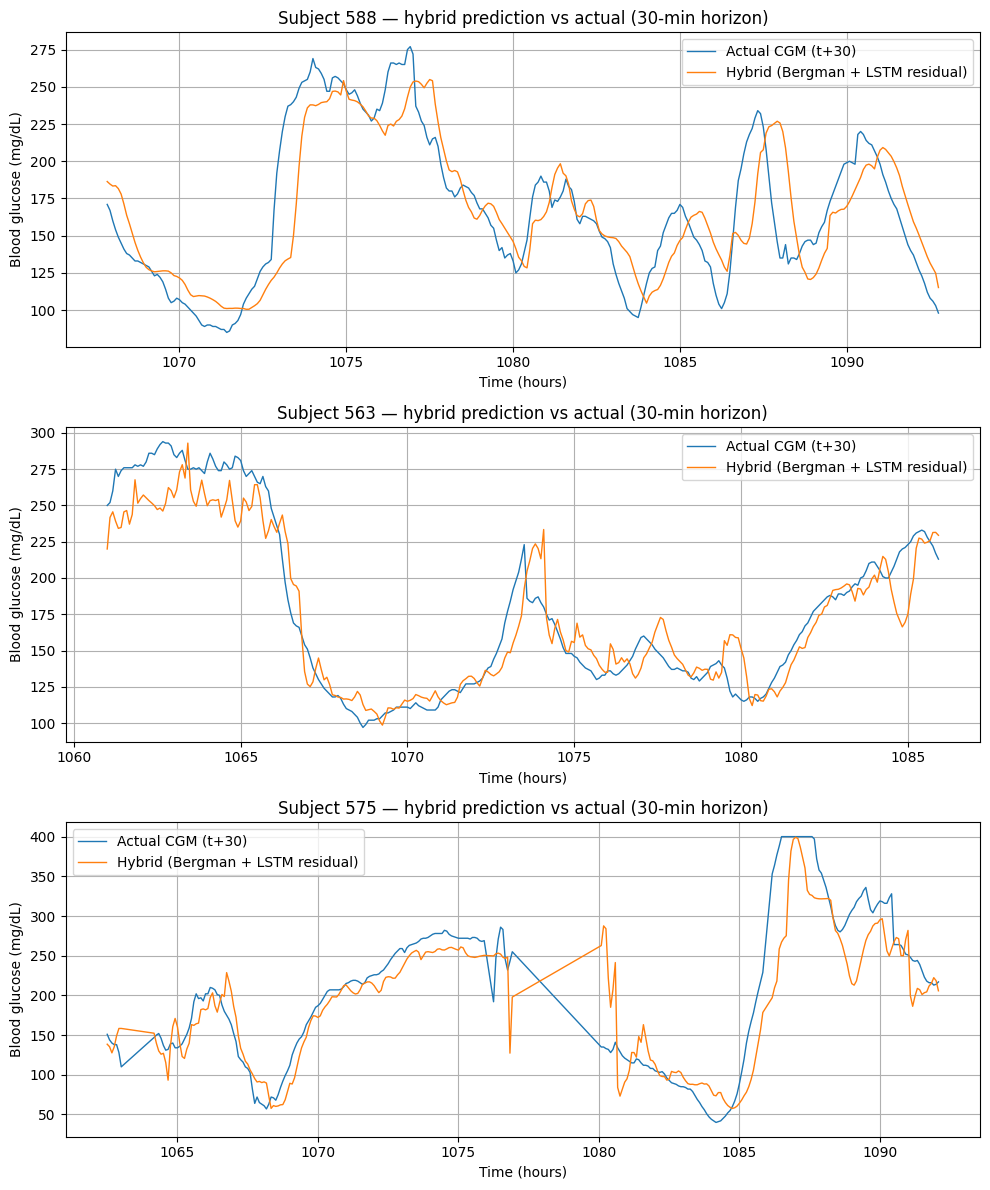

In [2]:
# Single-cell hybrid Bergman + LSTM predictor (one-cell notebook)
# Requirements: pandas, numpy, matplotlib, scikit-learn, tensorflow (keras)
# Put this cell in a notebook. Adjust parameters at top to scale.

import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings("ignore")

# --------------------
# USER-CONFIGURABLE PARAMETERS (keep it simple)
data_path = "../data/OhioT1DM.csv"
n_subjects = 3             # how many subjects to run & plot
pred_minutes = 30          # prediction horizon in minutes
dt_min = 5                 # sampling interval (minutes)
pred_steps = pred_minutes // dt_min  # 6 steps for 30 minutes
seq_len = 12               # LSTM input length (12*5min = 60min history)
epochs = 12
batch_size = 64
train_frac = 0.8           # per-subject train/test split
random_seed = 42
np.random.seed(random_seed)

# --------------------
# Simple discrete Bergman minimal model implementation (very small, tunable)
def bergman_predict(G0, I_trace, carbs_trace, basal_trace, bolus_trace, params):
    # Inputs: arrays for each time point, length T
    # Returns: array G_pred length T (starting from G0 at t=0)
    # params: dict with p1,p2,p3,Gb,Ib,carb_sensitivity (mg/dL per gram)
    p1,p2,p3 = params['p1'], params['p2'], params['p3']
    Gb, Ib = params['Gb'], params['Ib']
    carb_sens = params['carb_sens']  # mg/dL per gram of carbs applied as immediate infusion
    dt = dt_min / 60.0  # hours step (not strongly important for unit tuning)
    T = len(I_trace)
    G = np.zeros(T)
    X = 0.0  # insulin action compartment
    G_prev = G0
    for t in range(T):
        # simple approximation of plasma insulin relative to baseline:
        I = I_trace[t]
        # meal effect: proportional to carbs at that time (simple)
        meal = carb_sens * carbs_trace[t]
        # dx/dt = -p2*X + p3*(I - Ib)
        dX = (-p2 * X + p3 * (I - Ib)) * dt
        X = X + dX
        # dG/dt = - (p1 + X) * (G_prev - Gb) + meal_input - insulin independent clearance
        dG = ( - (p1 + X) * (G_prev - Gb) + meal ) * dt
        G_curr = G_prev + dG
        G[t] = G_curr
        G_prev = G_curr
    return G

# --------------------
# small helper to create supervised sequences for residual prediction
def make_sequences(features, target, seq_len, pred_steps):
    # features: (N, n_features) array
    # target: (N,) array - residuals
    Xs, ys = [], []
    N = len(target)
    # create samples where input is sequence ending at t and target is value at t+pred_steps
    for i in range(seq_len, N - pred_steps):
        Xs.append(features[i-seq_len:i])          # seq_len x n_features
        ys.append(target[i + pred_steps])         # single-step at horizon (we train to predict residual at +pred_steps)
    return np.array(Xs), np.array(ys)

# --------------------
# Load and prepare dataset
df = pd.read_csv(data_path, parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

# ensure subject ids are present and choose first n_subjects unique ids
subjects = df['id'].astype(int).unique()[:n_subjects]

fig, axes = plt.subplots(n_subjects, 1, figsize=(10, 4*n_subjects), sharex=False)
if n_subjects == 1:
    axes = [axes]

for idx, subj in enumerate(subjects):
    sub = df[df['id'].astype(int) == int(subj)].copy().reset_index(drop=True)
    # keep only times where CGM is present
    sub = sub.dropna(subset=['CGM']).reset_index(drop=True)
    if len(sub) < (seq_len + pred_steps + 10):
        print(f"subject {subj} has too little data, skipping")
        continue

    # basic feature columns we'll use for bergman and LSTM:
    # carbs (grams), bolus (units), basal (units per hr), we make a simple insulin trace I_trace = bolus + basal contribution
    carbs = sub['carbs'].fillna(0).values.astype(float)
    bolus = sub['bolus'].fillna(0).values.astype(float)
    basal = sub['basal'].fillna(0).values.astype(float)
    # Build a simple "plasma insulin" proxy: bolus injected at the sample, basal spread as constant
    I_trace = bolus + basal  # relative units; Bergman parameters tuned accordingly
    CGM = sub['CGM'].values.astype(float)

    # Bergman params (simple defaults, user can tune). Gb set to long-run median of CGM.
    params = {
        'p1': 0.03,     # glucose effectiveness
        'p2': 0.1,      # insulin decay in action compartment
        'p3': 0.002,    # insulin sensitivity (maps insulin deviation to action)
        'Gb': np.nanmedian(CGM),  # basal glucose target
        'Ib': np.median(I_trace), # basal insulin proxy
        'carb_sens': 0.2  # rough mg/dL per gram carbs per hour (simple tuning knob)
    }

    # Compute Bergman predictions for entire timeline (one-step ahead series aligned with CGM samples)
    G0 = CGM[0]
    bgm_pred_full = bergman_predict(G0, I_trace, carbs, basal, bolus, params)

    # Residual series = actual - bergman
    residuals = CGM - bgm_pred_full

    # Build features for LSTM: we will feed residual history + current carbs and insulin as scalar features per time step
    # shape: (N, n_features)
    features = np.vstack([residuals, carbs, I_trace]).T

    # scale features (use scalers per subject to keep simple)
    fscaler = StandardScaler()
    features_scaled = fscaler.fit_transform(features)
    rscaler = StandardScaler()
    residuals_scaled = rscaler.fit_transform(residuals.reshape(-1,1)).flatten()

    # create supervised sequences
    X, y = make_sequences(features_scaled, residuals_scaled, seq_len, pred_steps)
    # train/test split
    n_train = int(len(X) * train_frac)
    X_train, X_test = X[:n_train], X[n_train:]
    y_train, y_test = y[:n_train], y[n_train:]

    # build a small LSTM regressor that outputs a single residual value at horizon (+pred_steps)
    model = Sequential([
        LSTM(32, input_shape=(X_train.shape[1], X_train.shape[2]), activation='tanh'),
        Dense(16, activation='relu'),
        Dense(1)  # predicted residual (scaled)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=0)
    model.fit(X_train, y_train, validation_split=0.1, epochs=epochs,
              batch_size=batch_size, callbacks=[es], verbose=0)

    # Predict residuals on test sequences
    y_pred_scaled = model.predict(X_test).flatten()
    y_pred = rscaler.inverse_transform(y_pred_scaled.reshape(-1,1)).flatten()

    # Align predictions with time so that each sample predicted corresponds to time t+pred_steps
    # Recall we created sequences starting at index seq_len and target was at index i+pred_steps
    # So test sample i in X_test corresponds to original timestamp index = seq_len + n_train + i
    test_start_index = seq_len + n_train
    pred_time_indices = np.arange(test_start_index + pred_steps, test_start_index + pred_steps + len(y_pred))
    # safety clip
    pred_time_indices = pred_time_indices[pred_time_indices < len(CGM)]
    y_pred = y_pred[:len(pred_time_indices)]

    # Bergman forecast for those same future indices: bgm_pred_full at time t+pred_steps (we already have full bgm run)
    bgm_at_horizon = bgm_pred_full[pred_time_indices]

    hybrid_pred = bgm_at_horizon + y_pred  # final hybrid prediction at +pred_minutes

    # actual CGM at horizon
    actual_at_horizon = CGM[pred_time_indices]
    times = sub['date'].values[pred_time_indices]

    # Plot a window of results (choose up to first 300 predicted points to keep plot readable)
    window = slice(0, min(300, len(hybrid_pred)))
    t_plot = times[window]
    # convert times to hours relative to start to match request for x-axis (hours)
    t0 = pd.to_datetime(sub['date'].iloc[0])
    t_hours = (pd.to_datetime(t_plot) - t0) / pd.Timedelta(hours=1)

    ax = axes[idx]
    ax.plot(t_hours, actual_at_horizon[window], label='Actual CGM (t+30)', linewidth=1)
    ax.plot(t_hours, hybrid_pred[window], label='Hybrid (Bergman + LSTM residual)', linewidth=1)
    ax.set_title(f"Subject {subj} — hybrid prediction vs actual (30-min horizon)")
    ax.set_xlabel("Time (hours)")
    ax.set_ylabel("Blood glucose (mg/dL)")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# --- Metrics evaluation cell (append to single-cell notebook) ---
# This cell computes glucose-weighted metrics (gRMSE, gMAE), RMSE/MAE/MAPE
# for the hybrid Bergman + LSTM residual-corrector implementation above.
# It rebuilds the training/test split per subject (same logic as the model cell)
# and aggregates final-step predictions across the SUBJECTS_TO_PLOT subjects.
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt
from collections import Counter
import matplotlib.pyplot as plt


# --- Glucose-weighted penalty functions (from your snippet) ---
def sigmoid(x, a, epsilon):
xi = (2 / epsilon) * (x - a - (epsilon / 2))
if x <= a:
return 0
elif a < x <= a + (epsilon / 2):
return -0.5 * xi ** 4 - xi ** 3 + xi + 0.5
elif a + (epsilon / 2) < x <= a + epsilon:
return 0.5 * xi ** 4 - xi ** 3 + xi + 0.5
else:
return 1




def sigmoid_hat(x, a, epsilon):
xi_hat = - (2 / epsilon) * (x - a + (epsilon / 2))
if x <= a - epsilon:
return 1
elif a - epsilon < x <= a - (epsilon / 2):
return 0.5 * xi_hat ** 4 - xi_hat ** 3 + xi_hat + 0.5
elif a - (epsilon / 2) < x <= a:
return -0.5 * xi_hat ** 4 - xi_hat ** 3 + xi_hat + 0.5
else:
return 0




def penalty(g, g_hat):
alpha_L = 1.5; alpha_H = 1
beta_L = 30; beta_H = 100
gamma_L = 10; gamma_H = 20
T_L = 85; T_H = 155
sigma_T_L = sigmoid_hat(g, T_L, beta_L)
sigma_gamma_L = sigmoid(g_hat, g, gamma_L)
sigma_T_H = sigmoid(g, T_H, beta_H)
sigma_gamma_H = sigmoid_hat(g_hat, g, gamma_H)
return (1 + alpha_L * sigma_T_L * sigma_gamma_L + alpha_H * sigma_T_H * sigma_gamma_H)




def glucose_rmse(y_true, y_pred):
y_true = np.asarray(y_true, dtype=float)
y_pred = np.asarray(y_pred, dtype=float)
mask = np.isfinite(y_true) & np.isfinite(y_pred)
y_true, y_pred = y_true[mask], y_pred[mask]
penalties = np.array([penalty(g, g_hat) for g, g_hat in zip(y_true, y_pred)])
mse = np.nanmean(((y_true - y_pred) ** 2) * penalties)
return np.sqrt(mse)




def glucose_mae(y_true, y_pred):
y_true = np.asarray(y_true, dtype=float)